# Bulk, small- and large-species ROM comparison

## Purpose

This notebook compares non-intrusive reduced-order models for three related
coarse-grained fields:

$$
\phi_{\mathrm{bulk}},
\qquad
\phi_{\mathrm{small}},
\qquad
\phi_{\mathrm{large}}
=
\phi_{\mathrm{bulk}}
-
\phi_{\mathrm{small}}.
$$

The objectives are to determine:

1. how many POD modes each physical field requires;
2. whether the same neural surrogate performs equally well for all fields;
3. whether the increasingly segregated species fields are harder to predict
   than the total bulk field;
4. whether the reconstructed fields preserve the identity

$$
\phi_{\mathrm{bulk}}
=
\phi_{\mathrm{small}}
+
\phi_{\mathrm{large}}.
$$

The supplied bulk dataset does not contain a separate test folder. Ten
deterministic internal parameter cases are therefore reserved before model
selection. These cases are excluded from POD-rank and surrogate selection and
are evaluated only after the training-only procedure has been completed.

Within every cross-validation fold, the mean field, POD basis and surrogate
are fitted using only that fold's fitting simulations.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning,
)


def find_project_root(start: Path) -> Path:
    """Locate the repository root."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "results").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cg_phi_bulk_small_large_dataset.npz"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        "Processed three-field dataset was not found:\n"
        f"{PROCESSED_DATA_PATH}"
    )

with np.load(
    PROCESSED_DATA_PATH,
    allow_pickle=False,
) as data:
    x_grid = data["x"]
    z_grid = data["z"]
    output_time = data["time"]
    parameters = data["parameters"]
    simulation_numbers = data[
        "simulation_numbers"
    ]
    bulk_snapshot_matrix = data[
        "bulk_snapshots"
    ]
    small_snapshot_matrix = data[
        "small_snapshots"
    ]
    large_snapshot_matrix = data[
        "large_snapshots"
    ]


field_snapshot_matrices = {
    "bulk": bulk_snapshot_matrix,
    "small": small_snapshot_matrix,
    "large": large_snapshot_matrix,
}

print("Python executable:", sys.executable)
print("Project root:", PROJECT_ROOT)
print("Processed dataset:", PROCESSED_DATA_PATH)

print("\nDataset contents")
print("----------------")

print(
    "Parameters:",
    parameters.shape,
)

print(
    "Bulk snapshots:",
    bulk_snapshot_matrix.shape,
)

print(
    "Small snapshots:",
    small_snapshot_matrix.shape,
)

print(
    "Large snapshots:",
    large_snapshot_matrix.shape,
)

print(
    "Grid:",
    f"{x_grid.size} by {z_grid.size}",
)

print(
    "Output time:",
    output_time,
)


decomposition_error = float(
    np.max(
        np.abs(
            bulk_snapshot_matrix
            - small_snapshot_matrix
            - large_snapshot_matrix
        )
    )
)

print(
    "Maximum bulk-small-large decomposition error:",
    f"{decomposition_error:.6e}",
)

assert parameters.shape == (100,)

for field_name, snapshot_matrix in (
    field_snapshot_matrices.items()
):
    assert snapshot_matrix.shape == (
        10000,
        100,
    )

    assert np.isfinite(
        snapshot_matrix
    ).all(), field_name

assert x_grid.shape == (100,)
assert z_grid.shape == (100,)
assert decomposition_error < 1e-12

print("\nProcessed-dataset checks passed.")

Python executable: /Users/rallen/Documents/msc-rom-particle-systems/.venv/bin/python
Project root: /Users/rallen/Documents/msc-rom-particle-systems
Processed dataset: /Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_bulk_small_large_dataset.npz

Dataset contents
----------------
Parameters: (100,)
Bulk snapshots: (10000, 100)
Small snapshots: (10000, 100)
Large snapshots: (10000, 100)
Grid: 100 by 100
Output time: [1720.72]
Maximum bulk-small-large decomposition error: 0.000000e+00

Processed-dataset checks passed.


In [2]:
candidate_ranks = np.array(
    [
        1,
        2,
        3,
        4,
        6,
        8,
        10,
        15,
        20,
    ],
    dtype=int,
)

# Ten evenly distributed internal cases are reserved.
# The two parameter-range endpoints remain available for fitting,
# preventing interpolation folds from becoming extrapolation folds.
reserved_test_indices = np.array(
    [
        5,
        15,
        25,
        35,
        45,
        55,
        65,
        75,
        85,
        95,
    ],
    dtype=int,
)

all_indices = np.arange(
    parameters.size
)

model_training_indices = np.setdiff1d(
    all_indices,
    reserved_test_indices,
)

model_training_parameters = parameters[
    model_training_indices
]

reserved_test_parameters = parameters[
    reserved_test_indices
]

number_of_folds = 5

# Positions 0 and -1 correspond to the original parameter endpoints,
# which are retained in every fitting set.
internal_training_positions = np.arange(
    1,
    model_training_indices.size - 1,
)

validation_position_folds = [
    internal_training_positions[
        np.arange(
            internal_training_positions.size
        ) % number_of_folds
        == fold_index
    ]
    for fold_index in range(
        number_of_folds
    )
]

validation_index_folds = [
    model_training_indices[
        validation_positions
    ]
    for validation_positions in (
        validation_position_folds
    )
]


print("Candidate POD ranks:")
print(candidate_ranks)

print("\nReserved test cases:")
print(
    "Indices:",
    reserved_test_indices,
)

print(
    "Parameters:",
    reserved_test_parameters,
)

print(
    "Test parameter range:",
    f"{reserved_test_parameters.min():.6f}",
    "to",
    f"{reserved_test_parameters.max():.6f}",
)

print(
    "\nModel-selection training cases:",
    model_training_indices.size,
)

print(
    "Reserved test cases:",
    reserved_test_indices.size,
)


print("\nValidation folds:")

for fold_number, validation_indices in enumerate(
    validation_index_folds,
    start=1,
):
    fitting_indices = np.setdiff1d(
        model_training_indices,
        validation_indices,
    )

    print(
        f"  Fold {fold_number}: "
        f"{fitting_indices.size} fitting cases, "
        f"{validation_indices.size} validation cases, "
        f"validation range "
        f"{parameters[validation_indices].min():.6f} to "
        f"{parameters[validation_indices].max():.6f}"
    )


validation_union = np.concatenate(
    validation_index_folds
)

assert np.intersect1d(
    model_training_indices,
    reserved_test_indices,
).size == 0

assert np.intersect1d(
    validation_union,
    reserved_test_indices,
).size == 0

assert np.unique(
    validation_union
).size == (
    model_training_indices.size - 2
)

assert 0 in model_training_indices
assert 99 in model_training_indices

assert not np.any(
    validation_union == 0
)

assert not np.any(
    validation_union == 99
)

print("\nSplit and validation-fold checks passed.")

Candidate POD ranks:
[ 1  2  3  4  6  8 10 15 20]

Reserved test cases:
Indices: [ 5 15 25 35 45 55 65 75 85 95]
Parameters: [1.050505 1.151515 1.252525 1.353535 1.454545 1.555556 1.656566 1.757576
 1.858586 1.959596]
Test parameter range: 1.050505 to 1.959596

Model-selection training cases: 90
Reserved test cases: 10

Validation folds:
  Fold 1: 72 fitting cases, 18 validation cases, validation range 1.010101 to 1.969697
  Fold 2: 72 fitting cases, 18 validation cases, validation range 1.020202 to 1.979798
  Fold 3: 72 fitting cases, 18 validation cases, validation range 1.030303 to 1.989899
  Fold 4: 73 fitting cases, 17 validation cases, validation range 1.040404 to 1.939394
  Fold 5: 73 fitting cases, 17 validation cases, validation range 1.060606 to 1.949495

Split and validation-fold checks passed.


In [3]:
def relative_snapshot_errors(
    reference_snapshots: np.ndarray,
    predicted_snapshots: np.ndarray,
) -> np.ndarray:
    """Calculate one relative L2 error per snapshot column."""
    reference_norms = np.linalg.norm(
        reference_snapshots,
        axis=0,
    )

    if np.any(
        reference_norms == 0.0
    ):
        raise ValueError(
            "A reference snapshot has zero norm."
        )

    return (
        np.linalg.norm(
            reference_snapshots
            - predicted_snapshots,
            axis=0,
        )
        / reference_norms
    )


def predict_linear_coefficients(
    fitting_parameters: np.ndarray,
    fitting_coefficients: np.ndarray,
    query_parameters: np.ndarray,
) -> np.ndarray:
    """Predict each POD coefficient using linear interpolation."""
    sorting_indices = np.argsort(
        fitting_parameters
    )

    sorted_parameters = fitting_parameters[
        sorting_indices
    ]

    sorted_coefficients = fitting_coefficients[
        :,
        sorting_indices,
    ]

    return np.vstack(
        [
            np.interp(
                query_parameters,
                sorted_parameters,
                sorted_coefficients[
                    mode_index,
                    :,
                ],
            )
            for mode_index in range(
                sorted_coefficients.shape[0]
            )
        ]
    )


def predict_neural_coefficients(
    fitting_parameters: np.ndarray,
    fitting_coefficients: np.ndarray,
    query_parameters: np.ndarray,
    random_state: int,
    hidden_layer_sizes: tuple[int, ...] = (16,),
    alpha: float = 0.1,
) -> np.ndarray:
    """
    Fit a standardised regularised neural network and predict
    POD coefficients.
    """
    input_scaler = StandardScaler()
    output_scaler = StandardScaler()

    fitting_inputs = input_scaler.fit_transform(
        fitting_parameters.reshape(-1, 1)
    )

    query_inputs = input_scaler.transform(
        query_parameters.reshape(-1, 1)
    )

    fitting_outputs = output_scaler.fit_transform(
        fitting_coefficients.T
    )

    model = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="tanh",
        solver="lbfgs",
        alpha=alpha,
        max_iter=5000,
        random_state=random_state,
    )

    if fitting_outputs.shape[1] == 1:
        model.fit(
            fitting_inputs,
            fitting_outputs.ravel(),
        )
    else:
        model.fit(
            fitting_inputs,
            fitting_outputs,
        )

    scaled_predictions = np.asarray(
        model.predict(
            query_inputs
        )
    )

    if scaled_predictions.ndim == 1:
        scaled_predictions = (
            scaled_predictions.reshape(-1, 1)
        )

    predicted_coefficients = (
        output_scaler.inverse_transform(
            scaled_predictions
        ).T
    )

    if not np.isfinite(
        predicted_coefficients
    ).all():
        raise ValueError(
            "The neural surrogate produced "
            "non-finite predictions."
        )

    return predicted_coefficients


print("Shared ROM helper functions defined.")

print(
    "Fields to be modelled:",
    list(
        field_snapshot_matrices.keys()
    ),
)

Shared ROM helper functions defined.
Fields to be modelled: ['bulk', 'small', 'large']


In [4]:
multifield_fold_data = {
    field_name: []
    for field_name in field_snapshot_matrices
}

for field_name, snapshot_matrix in (
    field_snapshot_matrices.items()
):
    print(
        f"\nPreparing field: {field_name}"
    )

    for fold_number, validation_indices in enumerate(
        validation_index_folds,
        start=1,
    ):
        fitting_indices = np.setdiff1d(
            model_training_indices,
            validation_indices,
        )

        fitting_parameters = parameters[
            fitting_indices
        ]

        validation_parameters = parameters[
            validation_indices
        ]

        fitting_snapshots = snapshot_matrix[
            :,
            fitting_indices,
        ]

        validation_snapshots = snapshot_matrix[
            :,
            validation_indices,
        ]

        # Fitted using only this fold's fitting simulations.
        fold_mean_snapshot = fitting_snapshots.mean(
            axis=1,
            keepdims=True,
        )

        centred_fitting_snapshots = (
            fitting_snapshots
            - fold_mean_snapshot
        )

        (
            fold_modes,
            fold_singular_values,
            fold_right_vectors,
        ) = np.linalg.svd(
            centred_fitting_snapshots,
            full_matrices=False,
        )

        singular_value_energy = (
            fold_singular_values**2
        )

        cumulative_energy = np.cumsum(
            singular_value_energy
        ) / np.sum(
            singular_value_energy
        )

        multifield_fold_data[
            field_name
        ].append(
            {
                "field_name": field_name,
                "fold_number": fold_number,
                "fitting_indices": fitting_indices,
                "validation_indices": (
                    validation_indices
                ),
                "fitting_parameters": (
                    fitting_parameters
                ),
                "validation_parameters": (
                    validation_parameters
                ),
                "fitting_snapshots": (
                    fitting_snapshots
                ),
                "validation_snapshots": (
                    validation_snapshots
                ),
                "mean_snapshot": (
                    fold_mean_snapshot
                ),
                "centred_fitting_snapshots": (
                    centred_fitting_snapshots
                ),
                "modes": fold_modes,
                "singular_values": (
                    fold_singular_values
                ),
                "cumulative_energy": (
                    cumulative_energy
                ),
            }
        )

        print(
            f"  Fold {fold_number}: "
            f"{fitting_snapshots.shape[1]} fitting, "
            f"{validation_snapshots.shape[1]} validation"
        )


print("\nPrepared fold counts")
print("--------------------")

for field_name, folds in (
    multifield_fold_data.items()
):
    print(
        f"{field_name}: {len(folds)} folds"
    )

    assert len(folds) == number_of_folds

    for fold in folds:
        assert fold["modes"].shape[0] == 10000

        assert fold[
            "fitting_snapshots"
        ].shape[1] in (
            72,
            73,
        )

        assert np.isfinite(
            fold["singular_values"]
        ).all()

print(
    "\nLeakage-free multifield POD checks passed."
)


Preparing field: bulk
  Fold 1: 72 fitting, 18 validation
  Fold 2: 72 fitting, 18 validation
  Fold 3: 72 fitting, 18 validation
  Fold 4: 73 fitting, 17 validation
  Fold 5: 73 fitting, 17 validation

Preparing field: small
  Fold 1: 72 fitting, 18 validation
  Fold 2: 72 fitting, 18 validation
  Fold 3: 72 fitting, 18 validation
  Fold 4: 73 fitting, 17 validation
  Fold 5: 73 fitting, 17 validation

Preparing field: large
  Fold 1: 72 fitting, 18 validation
  Fold 2: 72 fitting, 18 validation
  Fold 3: 72 fitting, 18 validation
  Fold 4: 73 fitting, 17 validation
  Fold 5: 73 fitting, 17 validation

Prepared fold counts
--------------------
bulk: 5 folds
small: 5 folds
large: 5 folds

Leakage-free multifield POD checks passed.


In [5]:
multifield_linear_records = []

for field_name, folds in (
    multifield_fold_data.items()
):
    print(
        f"\nLinear surrogate: {field_name}"
    )

    for fold in folds:
        centred_validation_snapshots = (
            fold["validation_snapshots"]
            - fold["mean_snapshot"]
        )

        for rank in candidate_ranks:
            basis = fold["modes"][
                :,
                :rank,
            ]

            fitting_coefficients = (
                basis.T
                @ fold[
                    "centred_fitting_snapshots"
                ]
            )

            projected_validation_coefficients = (
                basis.T
                @ centred_validation_snapshots
            )

            projected_validation_snapshots = (
                fold["mean_snapshot"]
                + basis
                @ projected_validation_coefficients
            )

            projection_errors = (
                relative_snapshot_errors(
                    fold[
                        "validation_snapshots"
                    ],
                    projected_validation_snapshots,
                )
            )

            predicted_coefficients = (
                predict_linear_coefficients(
                    fitting_parameters=fold[
                        "fitting_parameters"
                    ],
                    fitting_coefficients=(
                        fitting_coefficients
                    ),
                    query_parameters=fold[
                        "validation_parameters"
                    ],
                )
            )

            predicted_validation_snapshots = (
                fold["mean_snapshot"]
                + basis
                @ predicted_coefficients
            )

            surrogate_errors = (
                relative_snapshot_errors(
                    fold[
                        "validation_snapshots"
                    ],
                    predicted_validation_snapshots,
                )
            )

            captured_energy = float(
                fold["cumulative_energy"][
                    rank - 1
                ]
            )

            for local_index, validation_index in enumerate(
                fold["validation_indices"]
            ):
                multifield_linear_records.append(
                    {
                        "field": field_name,
                        "fold": fold[
                            "fold_number"
                        ],
                        "rank": int(rank),
                        "original_index": int(
                            validation_index
                        ),
                        "size_ratio": float(
                            fold[
                                "validation_parameters"
                            ][local_index]
                        ),
                        "captured_energy": (
                            captured_energy
                        ),
                        "projection_error": float(
                            projection_errors[
                                local_index
                            ]
                        ),
                        "surrogate_error": float(
                            surrogate_errors[
                                local_index
                            ]
                        ),
                        "excess_error": float(
                            surrogate_errors[
                                local_index
                            ]
                            - projection_errors[
                                local_index
                            ]
                        ),
                    }
                )

        print(
            f"  Completed fold "
            f"{fold['fold_number']}"
        )


multifield_linear_results = pd.DataFrame(
    multifield_linear_records
)

multifield_linear_summary = (
    multifield_linear_results
    .groupby(
        [
            "field",
            "rank",
        ],
        as_index=False,
    )
    .agg(
        mean_captured_energy=(
            "captured_energy",
            "mean",
        ),
        mean_projection_error=(
            "projection_error",
            "mean",
        ),
        maximum_projection_error=(
            "projection_error",
            "max",
        ),
        mean_linear_error=(
            "surrogate_error",
            "mean",
        ),
        median_linear_error=(
            "surrogate_error",
            "median",
        ),
        maximum_linear_error=(
            "surrogate_error",
            "max",
        ),
        mean_linear_excess_error=(
            "excess_error",
            "mean",
        ),
    )
)


print(
    "\nLeakage-free linear-surrogate summary:"
)

display(
    multifield_linear_summary
)


Linear surrogate: bulk
  Completed fold 1
  Completed fold 2
  Completed fold 3
  Completed fold 4
  Completed fold 5

Linear surrogate: small
  Completed fold 1
  Completed fold 2
  Completed fold 3
  Completed fold 4
  Completed fold 5

Linear surrogate: large
  Completed fold 1
  Completed fold 2
  Completed fold 3
  Completed fold 4
  Completed fold 5

Leakage-free linear-surrogate summary:


,field,rank,mean_captured_energy,mean_projection_error,maximum_projection_error,mean_linear_error,median_linear_error,maximum_linear_error,mean_linear_excess_error
0,bulk,1,0.943396,0.004247,0.011427,0.004508,0.004143,0.011504,0.000260
1,bulk,2,0.973800,0.003236,0.005157,0.004041,0.003893,0.006699,0.000805
2,bulk,3,0.980469,0.002865,0.004745,0.003955,0.003755,0.006565,0.001089
3,bulk,4,0.983761,0.002670,0.003839,0.003949,0.003795,0.006448,0.001279
4,bulk,6,0.987619,0.002439,0.003134,0.004059,0.003966,0.006546,0.001620
5,bulk,8,0.990155,0.002234,0.002925,0.004114,0.003993,0.006579,0.001880
6,bulk,10,0.991816,0.002119,0.002571,0.004164,0.004082,0.006572,0.002045
7,bulk,15,0.994333,0.001929,0.002426,0.004222,0.004154,0.006570,0.002293
8,bulk,20,0.995876,0.001798,0.002302,0.004262,0.004171,0.006606,0.002464
9,large,1,0.966173,0.026490,0.070944,0.027167,0.025824,0.071779,0.000677


In [6]:
multifield_neural_records = []

field_random_offsets = {
    "bulk": 1000,
    "small": 2000,
    "large": 3000,
}

total_neural_models = (
    len(field_snapshot_matrices)
    * number_of_folds
    * candidate_ranks.size
)

completed_neural_models = 0

for field_name, folds in (
    multifield_fold_data.items()
):
    print(
        f"\nNeural surrogate: {field_name}"
    )

    for fold in folds:
        centred_validation_snapshots = (
            fold["validation_snapshots"]
            - fold["mean_snapshot"]
        )

        for rank in candidate_ranks:
            basis = fold["modes"][
                :,
                :rank,
            ]

            fitting_coefficients = (
                basis.T
                @ fold[
                    "centred_fitting_snapshots"
                ]
            )

            projected_validation_coefficients = (
                basis.T
                @ centred_validation_snapshots
            )

            projected_validation_snapshots = (
                fold["mean_snapshot"]
                + basis
                @ projected_validation_coefficients
            )

            projection_errors = (
                relative_snapshot_errors(
                    fold[
                        "validation_snapshots"
                    ],
                    projected_validation_snapshots,
                )
            )

            random_state = (
                field_random_offsets[
                    field_name
                ]
                + 100
                * fold["fold_number"]
                + int(rank)
            )

            predicted_coefficients = (
                predict_neural_coefficients(
                    fitting_parameters=fold[
                        "fitting_parameters"
                    ],
                    fitting_coefficients=(
                        fitting_coefficients
                    ),
                    query_parameters=fold[
                        "validation_parameters"
                    ],
                    random_state=random_state,
                    hidden_layer_sizes=(16,),
                    alpha=0.1,
                )
            )

            predicted_validation_snapshots = (
                fold["mean_snapshot"]
                + basis
                @ predicted_coefficients
            )

            surrogate_errors = (
                relative_snapshot_errors(
                    fold[
                        "validation_snapshots"
                    ],
                    predicted_validation_snapshots,
                )
            )

            captured_energy = float(
                fold["cumulative_energy"][
                    rank - 1
                ]
            )

            for local_index, validation_index in enumerate(
                fold["validation_indices"]
            ):
                multifield_neural_records.append(
                    {
                        "field": field_name,
                        "fold": fold[
                            "fold_number"
                        ],
                        "rank": int(rank),
                        "original_index": int(
                            validation_index
                        ),
                        "size_ratio": float(
                            fold[
                                "validation_parameters"
                            ][local_index]
                        ),
                        "captured_energy": (
                            captured_energy
                        ),
                        "projection_error": float(
                            projection_errors[
                                local_index
                            ]
                        ),
                        "surrogate_error": float(
                            surrogate_errors[
                                local_index
                            ]
                        ),
                        "excess_error": float(
                            surrogate_errors[
                                local_index
                            ]
                            - projection_errors[
                                local_index
                            ]
                        ),
                        "random_state": int(
                            random_state
                        ),
                    }
                )

            completed_neural_models += 1

            print(
                f"  Model "
                f"{completed_neural_models}/"
                f"{total_neural_models}: "
                f"fold {fold['fold_number']}, "
                f"rank {rank}"
            )


multifield_neural_results = pd.DataFrame(
    multifield_neural_records
)

multifield_neural_summary = (
    multifield_neural_results
    .groupby(
        [
            "field",
            "rank",
        ],
        as_index=False,
    )
    .agg(
        mean_neural_error=(
            "surrogate_error",
            "mean",
        ),
        median_neural_error=(
            "surrogate_error",
            "median",
        ),
        maximum_neural_error=(
            "surrogate_error",
            "max",
        ),
        mean_neural_excess_error=(
            "excess_error",
            "mean",
        ),
    )
)


multifield_rank_summary = (
    multifield_linear_summary
    .merge(
        multifield_neural_summary,
        on=[
            "field",
            "rank",
        ],
        how="inner",
    )
)


print(
    "\nJoint leakage-free multifield results:"
)

display(
    multifield_rank_summary
)


Neural surrogate: bulk
  Model 1/135: fold 1, rank 1
  Model 2/135: fold 1, rank 2
  Model 3/135: fold 1, rank 3
  Model 4/135: fold 1, rank 4
  Model 5/135: fold 1, rank 6
  Model 6/135: fold 1, rank 8
  Model 7/135: fold 1, rank 10
  Model 8/135: fold 1, rank 15
  Model 9/135: fold 1, rank 20
  Model 10/135: fold 2, rank 1
  Model 11/135: fold 2, rank 2
  Model 12/135: fold 2, rank 3
  Model 13/135: fold 2, rank 4
  Model 14/135: fold 2, rank 6
  Model 15/135: fold 2, rank 8
  Model 16/135: fold 2, rank 10
  Model 17/135: fold 2, rank 15
  Model 18/135: fold 2, rank 20
  Model 19/135: fold 3, rank 1
  Model 20/135: fold 3, rank 2
  Model 21/135: fold 3, rank 3
  Model 22/135: fold 3, rank 4
  Model 23/135: fold 3, rank 6
  Model 24/135: fold 3, rank 8
  Model 25/135: fold 3, rank 10
  Model 26/135: fold 3, rank 15
  Model 27/135: fold 3, rank 20
  Model 28/135: fold 4, rank 1
  Model 29/135: fold 4, rank 2
  Model 30/135: fold 4, rank 3
  Model 31/135: fold 4, rank 4
  Model 32/135:

,field,rank,mean_captured_energy,mean_projection_error,maximum_projection_error,mean_linear_error,median_linear_error,maximum_linear_error,mean_linear_excess_error,mean_neural_error,median_neural_error,maximum_neural_error,mean_neural_excess_error
0,bulk,1,0.943396,0.004247,0.011427,0.004508,0.004143,0.011504,0.000260,0.004466,0.004048,0.011933,0.000219
1,bulk,2,0.973800,0.003236,0.005157,0.004041,0.003893,0.006699,0.000805,0.003838,0.003619,0.005910,0.000602
2,bulk,3,0.980469,0.002865,0.004745,0.003955,0.003755,0.006565,0.001089,0.003682,0.003609,0.005730,0.000817
3,bulk,4,0.983761,0.002670,0.003839,0.003949,0.003795,0.006448,0.001279,0.003714,0.003612,0.005515,0.001044
4,bulk,6,0.987619,0.002439,0.003134,0.004059,0.003966,0.006546,0.001620,0.003676,0.003544,0.005621,0.001237
5,bulk,8,0.990155,0.002234,0.002925,0.004114,0.003993,0.006579,0.001880,0.003666,0.003520,0.005819,0.001432
6,bulk,10,0.991816,0.002119,0.002571,0.004164,0.004082,0.006572,0.002045,0.003695,0.003495,0.006015,0.001576
7,bulk,15,0.994333,0.001929,0.002426,0.004222,0.004154,0.006570,0.002293,0.003736,0.003642,0.005855,0.001807
8,bulk,20,0.995876,0.001798,0.002302,0.004262,0.004171,0.006606,0.002464,0.003886,0.003597,0.009536,0.002088
9,large,1,0.966173,0.026490,0.070944,0.027167,0.025824,0.071779,0.000677,0.027070,0.025625,0.071031,0.000580


Preliminary multifield rank selection
-------------------------------------


,field,preliminary_neural_rank,preliminary_neural_cv_error,preliminary_linear_rank,preliminary_linear_cv_error,captured_energy_at_neural_rank,projection_error_at_neural_rank
0,bulk,8,0.003666,4,0.003949,0.990155,0.002234
1,small,6,0.009091,3,0.009698,0.999095,0.005224
2,large,8,0.010139,3,0.010717,0.999126,0.005481


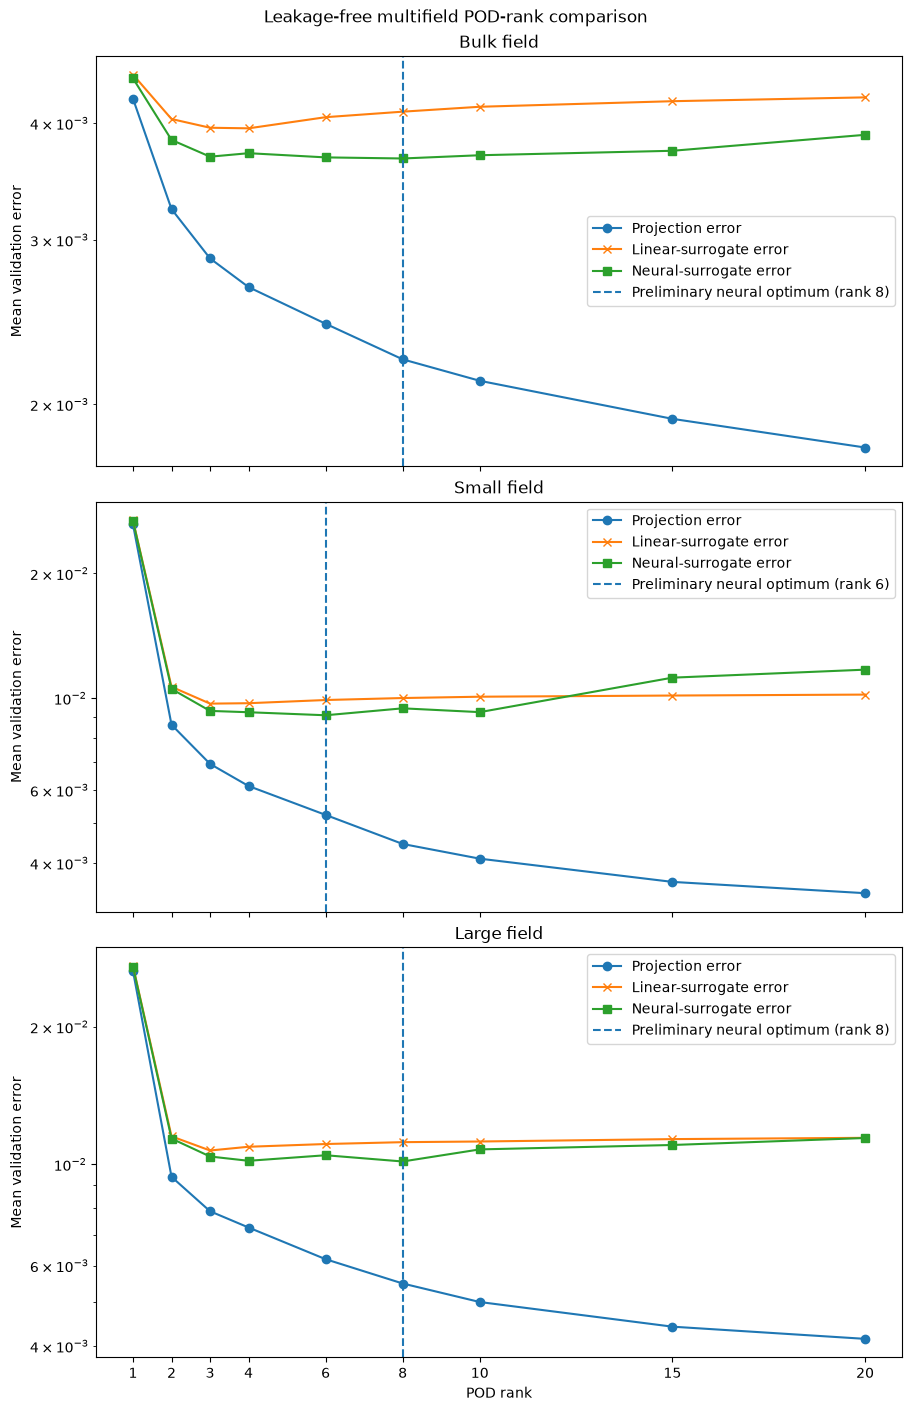

Saved detailed linear results:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_linear_cv_detailed.csv

Saved detailed neural results:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_neural_cv_detailed.csv

Saved rank summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_rank_cv_summary.csv

Saved preliminary selections:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_preliminary_rank_selection.csv

Saved rank-comparison figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_multifield_rank_cv_comparison.pdf


In [7]:
preliminary_rank_records = []

for field_name in (
    field_snapshot_matrices
):
    field_rows = (
        multifield_rank_summary.loc[
            multifield_rank_summary[
                "field"
            ]
            == field_name
        ]
    )

    best_neural_row = field_rows.loc[
        field_rows[
            "mean_neural_error"
        ].idxmin()
    ]

    best_linear_row = field_rows.loc[
        field_rows[
            "mean_linear_error"
        ].idxmin()
    ]

    preliminary_rank_records.append(
        {
            "field": field_name,
            "preliminary_neural_rank": int(
                best_neural_row["rank"]
            ),
            "preliminary_neural_cv_error": float(
                best_neural_row[
                    "mean_neural_error"
                ]
            ),
            "preliminary_linear_rank": int(
                best_linear_row["rank"]
            ),
            "preliminary_linear_cv_error": float(
                best_linear_row[
                    "mean_linear_error"
                ]
            ),
            "captured_energy_at_neural_rank": float(
                best_neural_row[
                    "mean_captured_energy"
                ]
            ),
            "projection_error_at_neural_rank": float(
                best_neural_row[
                    "mean_projection_error"
                ]
            ),
        }
    )


preliminary_rank_selection = pd.DataFrame(
    preliminary_rank_records
)

print("Preliminary multifield rank selection")
print("-------------------------------------")

display(
    preliminary_rank_selection
)


linear_detailed_path = (
    TABLE_DIR
    / "cg_phi_multifield_linear_cv_detailed.csv"
)

neural_detailed_path = (
    TABLE_DIR
    / "cg_phi_multifield_neural_cv_detailed.csv"
)

rank_summary_path = (
    TABLE_DIR
    / "cg_phi_multifield_rank_cv_summary.csv"
)

preliminary_selection_path = (
    TABLE_DIR
    / "cg_phi_multifield_preliminary_rank_selection.csv"
)

multifield_linear_results.to_csv(
    linear_detailed_path,
    index=False,
)

multifield_neural_results.to_csv(
    neural_detailed_path,
    index=False,
)

multifield_rank_summary.to_csv(
    rank_summary_path,
    index=False,
)

preliminary_rank_selection.to_csv(
    preliminary_selection_path,
    index=False,
)


figure, axes = plt.subplots(
    3,
    1,
    figsize=(9, 14),
    sharex=True,
    constrained_layout=True,
)

for axis, field_name in zip(
    axes,
    [
        "bulk",
        "small",
        "large",
    ],
):
    field_rows = (
        multifield_rank_summary.loc[
            multifield_rank_summary[
                "field"
            ]
            == field_name
        ]
        .sort_values(
            "rank"
        )
    )

    selected_rank = int(
        preliminary_rank_selection.loc[
            preliminary_rank_selection[
                "field"
            ]
            == field_name,
            "preliminary_neural_rank",
        ].iloc[0]
    )

    axis.semilogy(
        field_rows["rank"],
        field_rows[
            "mean_projection_error"
        ],
        marker="o",
        label="Projection error",
    )

    axis.semilogy(
        field_rows["rank"],
        field_rows[
            "mean_linear_error"
        ],
        marker="x",
        label="Linear-surrogate error",
    )

    axis.semilogy(
        field_rows["rank"],
        field_rows[
            "mean_neural_error"
        ],
        marker="s",
        label="Neural-surrogate error",
    )

    axis.axvline(
        selected_rank,
        linestyle="--",
        label=(
            "Preliminary neural optimum "
            f"(rank {selected_rank})"
        ),
    )

    axis.set_ylabel(
        "Mean validation error"
    )

    axis.set_title(
        f"{field_name.capitalize()} field"
    )

    axis.legend()


axes[-1].set_xlabel(
    "POD rank"
)

axes[-1].set_xticks(
    candidate_ranks
)

figure.suptitle(
    "Leakage-free multifield POD-rank comparison"
)

multifield_rank_figure_path = (
    FIGURE_DIR
    / "cg_phi_multifield_rank_cv_comparison.pdf"
)

figure.savefig(
    multifield_rank_figure_path,
    bbox_inches="tight",
)

plt.show()


print("Saved detailed linear results:")
print(linear_detailed_path)

print("\nSaved detailed neural results:")
print(neural_detailed_path)

print("\nSaved rank summary:")
print(rank_summary_path)

print("\nSaved preliminary selections:")
print(preliminary_selection_path)

print("\nSaved rank-comparison figure:")
print(multifield_rank_figure_path)

In [8]:
robust_candidate_ranks = {
    "bulk": np.array(
        [
            2,
            3,
            4,
            6,
            8,
            10,
        ],
        dtype=int,
    ),
    "small": np.array(
        [
            3,
            4,
            6,
            8,
            10,
        ],
        dtype=int,
    ),
    "large": np.array(
        [
            3,
            4,
            6,
            8,
            10,
        ],
        dtype=int,
    ),
}

repeat_seeds = [
    11,
    23,
    37,
    53,
    71,
]

multifield_repeated_seed_records = []

total_repeated_models = (
    sum(
        ranks.size
        for ranks in robust_candidate_ranks.values()
    )
    * len(repeat_seeds)
    * number_of_folds
)

completed_repeated_models = 0

for field_name, candidate_field_ranks in (
    robust_candidate_ranks.items()
):
    folds = multifield_fold_data[
        field_name
    ]

    print(
        f"\nRepeated-seed study: {field_name}"
    )

    for seed in repeat_seeds:
        for rank in candidate_field_ranks:
            all_validation_errors = []

            for fold in folds:
                basis = fold[
                    "modes"
                ][
                    :,
                    :rank,
                ]

                fitting_coefficients = (
                    basis.T
                    @ fold[
                        "centred_fitting_snapshots"
                    ]
                )

                model_random_state = (
                    field_random_offsets[
                        field_name
                    ]
                    + 1000 * seed
                    + 100 * fold[
                        "fold_number"
                    ]
                    + int(rank)
                )

                predicted_coefficients = (
                    predict_neural_coefficients(
                        fitting_parameters=fold[
                            "fitting_parameters"
                        ],
                        fitting_coefficients=(
                            fitting_coefficients
                        ),
                        query_parameters=fold[
                            "validation_parameters"
                        ],
                        random_state=(
                            model_random_state
                        ),
                        hidden_layer_sizes=(16,),
                        alpha=0.1,
                    )
                )

                predicted_snapshots = (
                    fold["mean_snapshot"]
                    + basis
                    @ predicted_coefficients
                )

                fold_errors = (
                    relative_snapshot_errors(
                        fold[
                            "validation_snapshots"
                        ],
                        predicted_snapshots,
                    )
                )

                all_validation_errors.append(
                    fold_errors
                )

                completed_repeated_models += 1

            repeated_errors = np.concatenate(
                all_validation_errors
            )

            multifield_repeated_seed_records.append(
                {
                    "field": field_name,
                    "seed": int(seed),
                    "rank": int(rank),
                    "mean_validation_error": float(
                        repeated_errors.mean()
                    ),
                    "median_validation_error": float(
                        np.median(
                            repeated_errors
                        )
                    ),
                    "maximum_validation_error": float(
                        repeated_errors.max()
                    ),
                    "standard_deviation_error": float(
                        repeated_errors.std()
                    ),
                }
            )

            print(
                f"  seed {seed:2d}, "
                f"rank {rank:2d}: "
                f"mean error = "
                f"{repeated_errors.mean():.6e}"
            )


multifield_repeated_seed_results = pd.DataFrame(
    multifield_repeated_seed_records
)

print(
    "\nCompleted neural models:",
    completed_repeated_models,
    "of",
    total_repeated_models,
)

assert (
    completed_repeated_models
    == total_repeated_models
)

display(
    multifield_repeated_seed_results
)


Repeated-seed study: bulk
  seed 11, rank  2: mean error = 3.851990e-03
  seed 11, rank  3: mean error = 3.695571e-03
  seed 11, rank  4: mean error = 3.677202e-03
  seed 11, rank  6: mean error = 3.634705e-03
  seed 11, rank  8: mean error = 3.664790e-03
  seed 11, rank 10: mean error = 3.646533e-03
  seed 23, rank  2: mean error = 3.835480e-03
  seed 23, rank  3: mean error = 3.673015e-03
  seed 23, rank  4: mean error = 3.695969e-03
  seed 23, rank  6: mean error = 3.661093e-03
  seed 23, rank  8: mean error = 3.686036e-03
  seed 23, rank 10: mean error = 3.676489e-03
  seed 37, rank  2: mean error = 3.841092e-03
  seed 37, rank  3: mean error = 3.696981e-03
  seed 37, rank  4: mean error = 3.662791e-03
  seed 37, rank  6: mean error = 3.675536e-03
  seed 37, rank  8: mean error = 3.687330e-03
  seed 37, rank 10: mean error = 3.695264e-03
  seed 53, rank  2: mean error = 3.844559e-03
  seed 53, rank  3: mean error = 3.684541e-03
  seed 53, rank  4: mean error = 3.680658e-03
  seed 

,field,seed,rank,mean_validation_error,median_validation_error,maximum_validation_error,standard_deviation_error
0,bulk,11,2,0.003852,0.003572,0.006543,0.000886
1,bulk,11,3,0.003696,0.003658,0.005576,0.000842
2,bulk,11,4,0.003677,0.003569,0.005428,0.000827
3,bulk,11,6,0.003635,0.003529,0.005305,0.000829
4,bulk,11,8,0.003665,0.003553,0.005547,0.000849
...,...,...,...,...,...,...,...
75,large,71,3,0.010252,0.009675,0.021586,0.003237
76,large,71,4,0.010185,0.009334,0.019313,0.003327
77,large,71,6,0.010458,0.009885,0.021099,0.003134
78,large,71,8,0.010458,0.009507,0.020705,0.003456


In [9]:
multifield_robust_rank_summary = (
    multifield_repeated_seed_results
    .groupby(
        [
            "field",
            "rank",
        ],
        as_index=False,
    )
    .agg(
        number_of_seeds=(
            "seed",
            "nunique",
        ),
        mean_cv_error=(
            "mean_validation_error",
            "mean",
        ),
        median_cv_error=(
            "mean_validation_error",
            "median",
        ),
        minimum_cv_error=(
            "mean_validation_error",
            "min",
        ),
        maximum_cv_error=(
            "mean_validation_error",
            "max",
        ),
        standard_deviation_across_seeds=(
            "mean_validation_error",
            "std",
        ),
        worst_case_validation_error=(
            "maximum_validation_error",
            "max",
        ),
    )
)

multifield_robust_rank_summary[
    "standard_error"
] = (
    multifield_robust_rank_summary[
        "standard_deviation_across_seeds"
    ]
    / np.sqrt(
        multifield_robust_rank_summary[
            "number_of_seeds"
        ]
    )
)


robust_selection_records = []

for field_name in (
    field_snapshot_matrices
):
    field_summary = (
        multifield_robust_rank_summary.loc[
            multifield_robust_rank_summary[
                "field"
            ]
            == field_name
        ]
        .sort_values(
            "rank"
        )
        .reset_index(
            drop=True
        )
    )

    best_row = field_summary.loc[
        field_summary[
            "mean_cv_error"
        ].idxmin()
    ]

    minimum_error_rank = int(
        best_row["rank"]
    )

    minimum_mean_error = float(
        best_row["mean_cv_error"]
    )

    minimum_standard_error = float(
        best_row["standard_error"]
    )

    one_standard_error_threshold = (
        minimum_mean_error
        + minimum_standard_error
    )

    eligible_rows = field_summary.loc[
        field_summary[
            "mean_cv_error"
        ]
        <= one_standard_error_threshold
    ]

    selected_rank = int(
        eligible_rows[
            "rank"
        ].min()
    )

    selected_robust_row = (
        field_summary.loc[
            field_summary[
                "rank"
            ]
            == selected_rank
        ]
        .iloc[0]
    )

    original_rank_row = (
        multifield_rank_summary.loc[
            (
                multifield_rank_summary[
                    "field"
                ]
                == field_name
            )
            & (
                multifield_rank_summary[
                    "rank"
                ]
                == selected_rank
            )
        ]
        .iloc[0]
    )

    preliminary_rank = int(
        preliminary_rank_selection.loc[
            preliminary_rank_selection[
                "field"
            ]
            == field_name,
            "preliminary_neural_rank",
        ].iloc[0]
    )

    robust_selection_records.append(
        {
            "field": field_name,
            "preliminary_rank": (
                preliminary_rank
            ),
            "minimum_error_rank": (
                minimum_error_rank
            ),
            "minimum_mean_cv_error": (
                minimum_mean_error
            ),
            "standard_error_at_minimum": (
                minimum_standard_error
            ),
            "one_standard_error_threshold": (
                one_standard_error_threshold
            ),
            "selected_one_se_rank": (
                selected_rank
            ),
            "selected_mean_cv_error": float(
                selected_robust_row[
                    "mean_cv_error"
                ]
            ),
            "selected_standard_error": float(
                selected_robust_row[
                    "standard_error"
                ]
            ),
            "selected_captured_energy": float(
                original_rank_row[
                    "mean_captured_energy"
                ]
            ),
            "selected_projection_error": float(
                original_rank_row[
                    "mean_projection_error"
                ]
            ),
        }
    )


multifield_robust_selection = pd.DataFrame(
    robust_selection_records
)

print("Repeated-seed multifield rank stability")
print("---------------------------------------")

display(
    multifield_robust_rank_summary
)

print("\nTraining-only rank selections")
print("-----------------------------")

display(
    multifield_robust_selection
)

for _, row in (
    multifield_robust_selection.iterrows()
):
    print(
        f"{row['field'].capitalize()}: "
        f"minimum-error rank "
        f"{int(row['minimum_error_rank'])}, "
        f"one-SE selected rank "
        f"{int(row['selected_one_se_rank'])}"
    )

Repeated-seed multifield rank stability
---------------------------------------


,field,rank,number_of_seeds,mean_cv_error,median_cv_error,minimum_cv_error,maximum_cv_error,standard_deviation_across_seeds,worst_case_validation_error,standard_error
0,bulk,2,5,0.003843,0.003842,0.003835,0.003852,0.000006,0.006543,0.000003
1,bulk,3,5,0.003689,0.003693,0.003673,0.003697,0.000010,0.005947,0.000004
2,bulk,4,5,0.003679,0.003677,0.003663,0.003696,0.000012,0.005815,0.000005
3,bulk,6,5,0.003664,0.003668,0.003635,0.003681,0.000018,0.005928,0.000008
4,bulk,8,5,0.003684,0.003686,0.003665,0.003697,0.000012,0.006476,0.000005
5,bulk,10,5,0.003679,0.003687,0.003647,0.003695,0.000020,0.006670,0.000009
6,large,3,5,0.010205,0.010209,0.010134,0.010252,0.000045,0.021586,0.000020
7,large,4,5,0.010267,0.010241,0.010185,0.010345,0.000073,0.023171,0.000033
8,large,6,5,0.010286,0.010261,0.010178,0.010458,0.000106,0.022857,0.000047
9,large,8,5,0.010401,0.010421,0.010259,0.010461,0.000083,0.023396,0.000037



Training-only rank selections
-----------------------------


,field,preliminary_rank,minimum_error_rank,minimum_mean_cv_error,standard_error_at_minimum,one_standard_error_threshold,selected_one_se_rank,selected_mean_cv_error,selected_standard_error,selected_captured_energy,selected_projection_error
0,bulk,8,6,0.003664,0.000008,0.003672,6,0.003664,0.000008,0.987619,0.002439
1,small,6,3,0.009220,0.000025,0.009244,3,0.009220,0.000025,0.998120,0.006937
2,large,8,3,0.010205,0.000020,0.010225,3,0.010205,0.000020,0.997744,0.007889


Bulk: minimum-error rank 6, one-SE selected rank 6
Small: minimum-error rank 3, one-SE selected rank 3
Large: minimum-error rank 3, one-SE selected rank 3


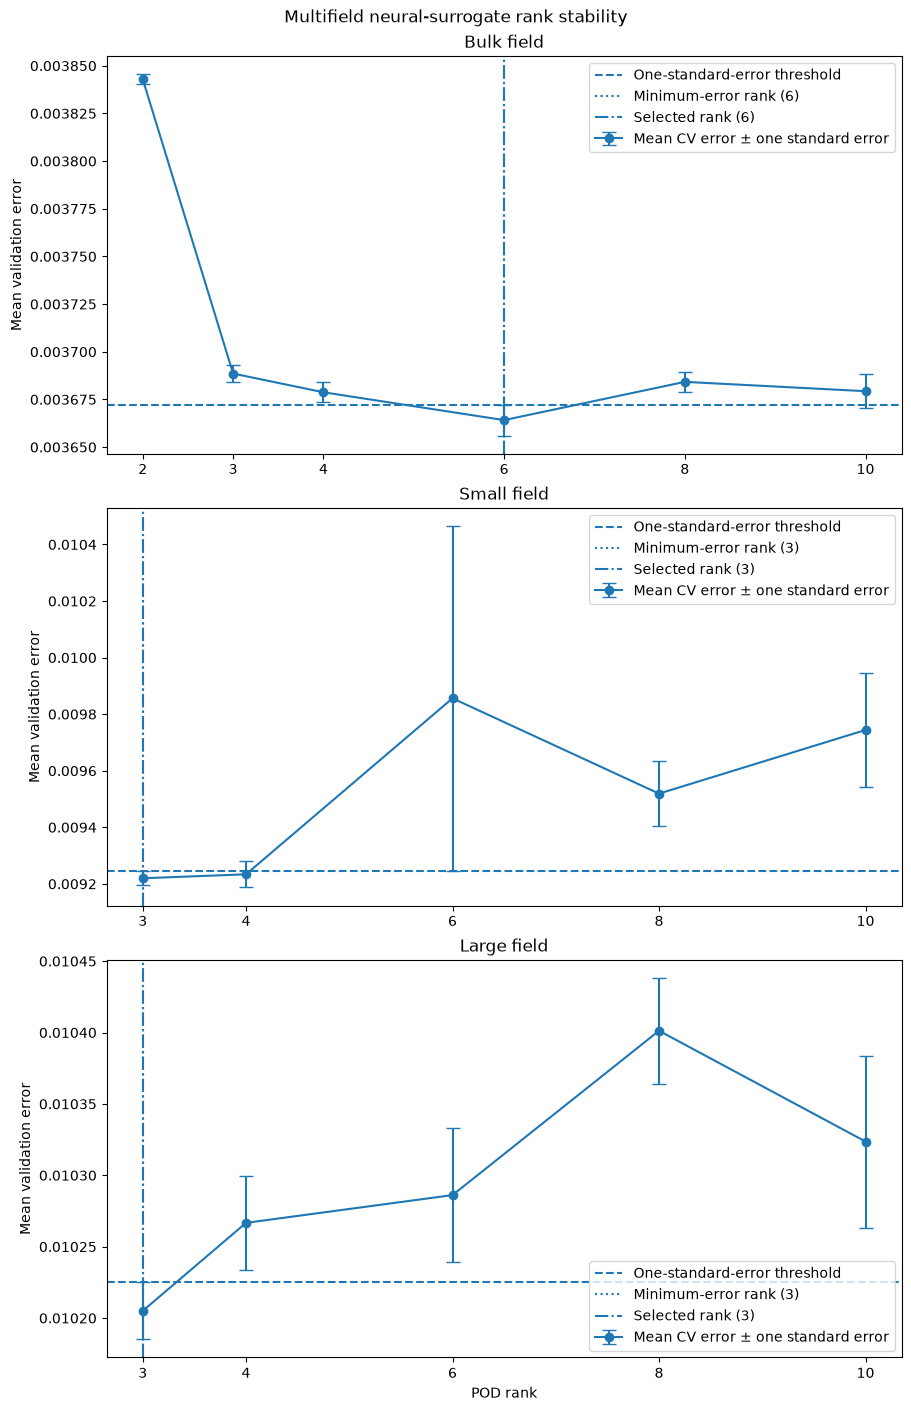

Saved repeated-seed results:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_repeated_seed_results.csv

Saved robust rank summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_robust_rank_summary.csv

Saved training-only rank selections:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_robust_rank_selection.csv

Saved rank-stability figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_multifield_rank_seed_stability.pdf


In [11]:
figure, axes = plt.subplots(
    3,
    1,
    figsize=(9, 14),
    sharex=False,
    constrained_layout=True,
)

for axis, field_name in zip(
    axes,
    [
        "bulk",
        "small",
        "large",
    ],
):
    field_summary = (
        multifield_robust_rank_summary.loc[
            multifield_robust_rank_summary[
                "field"
            ]
            == field_name
        ]
        .sort_values(
            "rank"
        )
    )

    selection_row = (
        multifield_robust_selection.loc[
            multifield_robust_selection[
                "field"
            ]
            == field_name
        ]
        .iloc[0]
    )

    minimum_error_rank = int(
        selection_row[
            "minimum_error_rank"
        ]
    )

    selected_rank = int(
        selection_row[
            "selected_one_se_rank"
        ]
    )

    threshold = float(
        selection_row[
            "one_standard_error_threshold"
        ]
    )

    axis.errorbar(
        field_summary[
            "rank"
        ],
        field_summary[
            "mean_cv_error"
        ],
        yerr=field_summary[
            "standard_error"
        ],
        marker="o",
        capsize=5,
        label=(
            "Mean CV error "
            "± one standard error"
        ),
    )

    axis.axhline(
        threshold,
        linestyle="--",
        label="One-standard-error threshold",
    )

    axis.axvline(
        minimum_error_rank,
        linestyle=":",
        label=(
            "Minimum-error rank "
            f"({minimum_error_rank})"
        ),
    )

    axis.axvline(
        selected_rank,
        linestyle="-.",
        label=(
            "Selected rank "
            f"({selected_rank})"
        ),
    )

    axis.set_xticks(
        field_summary[
            "rank"
        ]
    )

    axis.set_ylabel(
        "Mean validation error"
    )

    axis.set_title(
        f"{field_name.capitalize()} field"
    )

    axis.legend()


axes[-1].set_xlabel(
    "POD rank"
)

figure.suptitle(
    "Multifield neural-surrogate rank stability"
)

multifield_stability_figure_path = (
    FIGURE_DIR
    / "cg_phi_multifield_rank_seed_stability.pdf"
)

figure.savefig(
    multifield_stability_figure_path,
    bbox_inches="tight",
)

plt.show()


multifield_repeated_results_path = (
    TABLE_DIR
    / "cg_phi_multifield_repeated_seed_results.csv"
)

multifield_robust_summary_path = (
    TABLE_DIR
    / "cg_phi_multifield_robust_rank_summary.csv"
)

multifield_robust_selection_path = (
    TABLE_DIR
    / "cg_phi_multifield_robust_rank_selection.csv"
)

multifield_repeated_seed_results.to_csv(
    multifield_repeated_results_path,
    index=False,
)

multifield_robust_rank_summary.to_csv(
    multifield_robust_summary_path,
    index=False,
)

multifield_robust_selection.to_csv(
    multifield_robust_selection_path,
    index=False,
)

print("Saved repeated-seed results:")
print(multifield_repeated_results_path)

print("\nSaved robust rank summary:")
print(multifield_robust_summary_path)

print("\nSaved training-only rank selections:")
print(multifield_robust_selection_path)

print("\nSaved rank-stability figure:")
print(multifield_stability_figure_path)

In [12]:
final_model_random_states = {
    "bulk": 1042,
    "small": 2042,
    "large": 3042,
}

locked_multifield_models = {}
locked_model_records = []

for field_name, snapshot_matrix in (
    field_snapshot_matrices.items()
):
    selected_rank = int(
        multifield_robust_selection.loc[
            multifield_robust_selection[
                "field"
            ]
            == field_name,
            "selected_one_se_rank",
        ].iloc[0]
    )

    training_snapshots = snapshot_matrix[
        :,
        model_training_indices,
    ]

    training_parameters = parameters[
        model_training_indices
    ]

    mean_snapshot = training_snapshots.mean(
        axis=1,
        keepdims=True,
    )

    centred_training_snapshots = (
        training_snapshots
        - mean_snapshot
    )

    (
        full_modes,
        full_singular_values,
        full_right_vectors,
    ) = np.linalg.svd(
        centred_training_snapshots,
        full_matrices=False,
    )

    basis = full_modes[
        :,
        :selected_rank,
    ]

    training_coefficients = (
        basis.T
        @ centred_training_snapshots
    )

    cumulative_energy = np.cumsum(
        full_singular_values**2
    ) / np.sum(
        full_singular_values**2
    )

    captured_energy = float(
        cumulative_energy[
            selected_rank - 1
        ]
    )

    projected_training_snapshots = (
        mean_snapshot
        + basis
        @ training_coefficients
    )

    training_projection_errors = (
        relative_snapshot_errors(
            training_snapshots,
            projected_training_snapshots,
        )
    )

    input_scaler = StandardScaler()
    output_scaler = StandardScaler()

    scaled_training_inputs = (
        input_scaler.fit_transform(
            training_parameters.reshape(
                -1,
                1,
            )
        )
    )

    scaled_training_outputs = (
        output_scaler.fit_transform(
            training_coefficients.T
        )
    )

    neural_model = MLPRegressor(
        hidden_layer_sizes=(16,),
        activation="tanh",
        solver="lbfgs",
        alpha=0.1,
        max_iter=5000,
        random_state=(
            final_model_random_states[
                field_name
            ]
        ),
    )

    if selected_rank == 1:
        neural_model.fit(
            scaled_training_inputs,
            scaled_training_outputs.ravel(),
        )
    else:
        neural_model.fit(
            scaled_training_inputs,
            scaled_training_outputs,
        )

    locked_multifield_models[
        field_name
    ] = {
        "field_name": field_name,
        "rank": selected_rank,
        "mean_snapshot": mean_snapshot,
        "basis": basis,
        "singular_values": (
            full_singular_values
        ),
        "captured_energy": (
            captured_energy
        ),
        "training_parameters": (
            training_parameters
        ),
        "training_coefficients": (
            training_coefficients
        ),
        "input_scaler": input_scaler,
        "output_scaler": output_scaler,
        "neural_model": neural_model,
        "random_state": (
            final_model_random_states[
                field_name
            ]
        ),
    }

    locked_model_records.append(
        {
            "field": field_name,
            "selected_rank": selected_rank,
            "captured_energy": (
                captured_energy
            ),
            "mean_training_projection_error": float(
                training_projection_errors.mean()
            ),
            "maximum_training_projection_error": float(
                training_projection_errors.max()
            ),
            "training_cases": int(
                training_snapshots.shape[1]
            ),
            "reserved_test_cases": int(
                reserved_test_indices.size
            ),
            "random_state": int(
                final_model_random_states[
                    field_name
                ]
            ),
        }
    )

    print(
        f"{field_name.capitalize()} model locked: "
        f"rank {selected_rank}, "
        f"captured energy "
        f"{captured_energy:.8f}"
    )


locked_multifield_summary = pd.DataFrame(
    locked_model_records
)

print("\nLocked training-only models")
print("---------------------------")

display(
    locked_multifield_summary
)

locked_summary_path = (
    TABLE_DIR
    / "cg_phi_multifield_locked_model_summary.csv"
)

locked_multifield_summary.to_csv(
    locked_summary_path,
    index=False,
)

assert set(
    locked_multifield_models
) == {
    "bulk",
    "small",
    "large",
}

assert np.intersect1d(
    model_training_indices,
    reserved_test_indices,
).size == 0

print("\nSaved locked-model summary:")
print(locked_summary_path)

print(
    "\nThe reserved test fields have not "
    "been accessed by this cell."
)

Bulk model locked: rank 6, captured energy 0.98725372
Small model locked: rank 3, captured energy 0.99808668
Large model locked: rank 3, captured energy 0.99770017

Locked training-only models
---------------------------


,field,selected_rank,captured_energy,mean_training_projection_error,maximum_training_projection_error,training_cases,reserved_test_cases,random_state
0,bulk,6,0.987254,0.002203,0.003013,90,10,1042
1,small,3,0.998087,0.006676,0.013703,90,10,2042
2,large,3,0.997700,0.007590,0.012739,90,10,3042



Saved locked-model summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_locked_model_summary.csv

The reserved test fields have not been accessed by this cell.


In [13]:
def predict_locked_neural_model(
    locked_model: dict,
    query_parameters: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Predict POD coefficients and full snapshots using a locked model.
    """
    query_parameters = np.asarray(
        query_parameters,
        dtype=float,
    )

    scaled_inputs = locked_model[
        "input_scaler"
    ].transform(
        query_parameters.reshape(-1, 1)
    )

    scaled_coefficients = np.asarray(
        locked_model[
            "neural_model"
        ].predict(
            scaled_inputs
        )
    )

    if scaled_coefficients.ndim == 1:
        scaled_coefficients = (
            scaled_coefficients.reshape(-1, 1)
        )

    predicted_coefficients = locked_model[
        "output_scaler"
    ].inverse_transform(
        scaled_coefficients
    ).T

    predicted_snapshots = (
        locked_model["mean_snapshot"]
        + locked_model["basis"]
        @ predicted_coefficients
    )

    return (
        predicted_coefficients,
        predicted_snapshots,
    )


reserved_test_results_records = []
reserved_predictions = {}

for field_name, snapshot_matrix in (
    field_snapshot_matrices.items()
):
    locked_model = locked_multifield_models[
        field_name
    ]

    selected_rank = locked_model[
        "rank"
    ]

    exact_test_snapshots = snapshot_matrix[
        :,
        reserved_test_indices,
    ]

    centred_test_snapshots = (
        exact_test_snapshots
        - locked_model[
            "mean_snapshot"
        ]
    )

    projected_test_coefficients = (
        locked_model["basis"].T
        @ centred_test_snapshots
    )

    projected_test_snapshots = (
        locked_model["mean_snapshot"]
        + locked_model["basis"]
        @ projected_test_coefficients
    )

    linear_test_coefficients = (
        predict_linear_coefficients(
            fitting_parameters=locked_model[
                "training_parameters"
            ],
            fitting_coefficients=locked_model[
                "training_coefficients"
            ],
            query_parameters=(
                reserved_test_parameters
            ),
        )
    )

    linear_test_snapshots = (
        locked_model["mean_snapshot"]
        + locked_model["basis"]
        @ linear_test_coefficients
    )

    (
        neural_test_coefficients,
        neural_test_snapshots,
    ) = predict_locked_neural_model(
        locked_model,
        reserved_test_parameters,
    )

    projection_errors = (
        relative_snapshot_errors(
            exact_test_snapshots,
            projected_test_snapshots,
        )
    )

    linear_errors = (
        relative_snapshot_errors(
            exact_test_snapshots,
            linear_test_snapshots,
        )
    )

    neural_errors = (
        relative_snapshot_errors(
            exact_test_snapshots,
            neural_test_snapshots,
        )
    )

    reserved_predictions[
        field_name
    ] = {
        "exact_snapshots": (
            exact_test_snapshots
        ),
        "projected_snapshots": (
            projected_test_snapshots
        ),
        "linear_snapshots": (
            linear_test_snapshots
        ),
        "neural_snapshots": (
            neural_test_snapshots
        ),
        "projected_coefficients": (
            projected_test_coefficients
        ),
        "linear_coefficients": (
            linear_test_coefficients
        ),
        "neural_coefficients": (
            neural_test_coefficients
        ),
        "projection_errors": (
            projection_errors
        ),
        "linear_errors": (
            linear_errors
        ),
        "neural_errors": (
            neural_errors
        ),
    }

    for local_index, original_index in enumerate(
        reserved_test_indices
    ):
        reserved_test_results_records.append(
            {
                "field": field_name,
                "selected_rank": (
                    selected_rank
                ),
                "original_index": int(
                    original_index
                ),
                "simulation_number": int(
                    simulation_numbers[
                        original_index
                    ]
                ),
                "size_ratio": float(
                    parameters[
                        original_index
                    ]
                ),
                "projection_error": float(
                    projection_errors[
                        local_index
                    ]
                ),
                "linear_error": float(
                    linear_errors[
                        local_index
                    ]
                ),
                "neural_error": float(
                    neural_errors[
                        local_index
                    ]
                ),
                "neural_excess_above_projection": float(
                    neural_errors[
                        local_index
                    ]
                    - projection_errors[
                        local_index
                    ]
                ),
            }
        )

    print(
        f"{field_name.capitalize()}: "
        f"mean neural test error = "
        f"{neural_errors.mean():.6e}"
    )


reserved_test_results = pd.DataFrame(
    reserved_test_results_records
)

print(
    "\nReserved-case predictions completed."
)

assert set(
    reserved_predictions
) == {
    "bulk",
    "small",
    "large",
}

assert len(
    reserved_test_results
) == 30

Bulk: mean neural test error = 3.925730e-03
Small: mean neural test error = 9.404111e-03
Large: mean neural test error = 1.010350e-02

Reserved-case predictions completed.


Reserved-case multifield results
--------------------------------


,field,selected_rank,mean_projection_error,maximum_projection_error,mean_linear_error,maximum_linear_error,mean_neural_error,median_neural_error,maximum_neural_error,mean_neural_excess_error,selected_mean_cv_error,test_minus_cv_error
0,bulk,6,0.002324,0.002944,0.004741,0.006883,0.003926,0.003222,0.006923,0.001602,0.003664,0.000262
1,large,3,0.008225,0.015446,0.012481,0.021214,0.010104,0.008827,0.020069,0.001878,0.010205,-0.000102
2,small,3,0.007431,0.015311,0.011521,0.021546,0.009404,0.008118,0.020261,0.001973,0.009220,0.000184


Bulk: CV = 0.3664%, test = 0.3926%, maximum test = 0.6923%
Large: CV = 1.0205%, test = 1.0104%, maximum test = 2.0069%
Small: CV = 0.9220%, test = 0.9404%, maximum test = 2.0261%


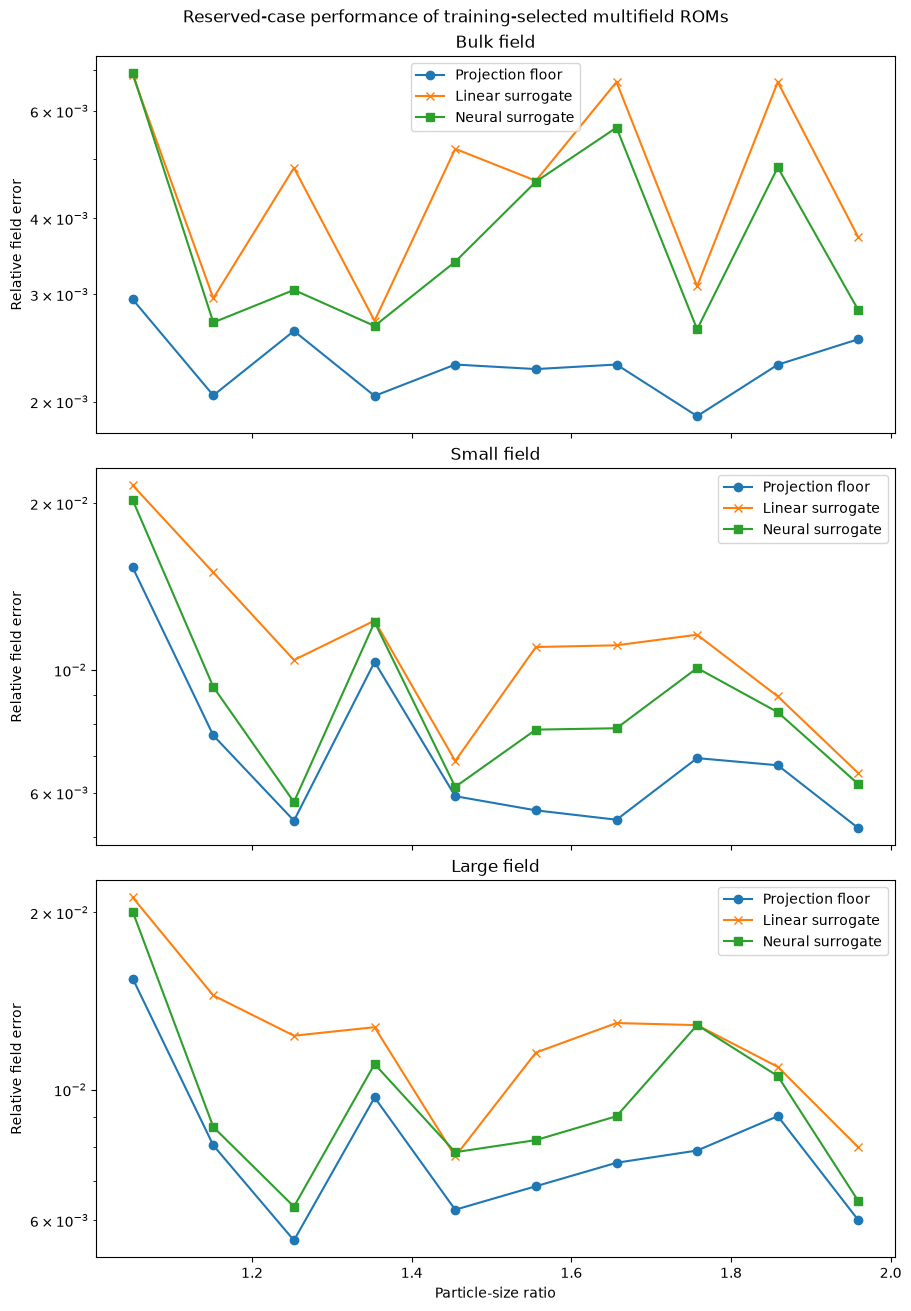

Saved detailed results:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_reserved_test_detailed.csv

Saved summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_reserved_test_summary.csv

Saved test-error figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_multifield_reserved_test_errors.pdf


In [14]:
reserved_test_summary = (
    reserved_test_results
    .groupby(
        [
            "field",
            "selected_rank",
        ],
        as_index=False,
    )
    .agg(
        mean_projection_error=(
            "projection_error",
            "mean",
        ),
        maximum_projection_error=(
            "projection_error",
            "max",
        ),
        mean_linear_error=(
            "linear_error",
            "mean",
        ),
        maximum_linear_error=(
            "linear_error",
            "max",
        ),
        mean_neural_error=(
            "neural_error",
            "mean",
        ),
        median_neural_error=(
            "neural_error",
            "median",
        ),
        maximum_neural_error=(
            "neural_error",
            "max",
        ),
        mean_neural_excess_error=(
            "neural_excess_above_projection",
            "mean",
        ),
    )
)

reserved_test_summary = (
    reserved_test_summary.merge(
        multifield_robust_selection[
            [
                "field",
                "selected_mean_cv_error",
            ]
        ],
        on="field",
        how="left",
    )
)

reserved_test_summary[
    "test_minus_cv_error"
] = (
    reserved_test_summary[
        "mean_neural_error"
    ]
    - reserved_test_summary[
        "selected_mean_cv_error"
    ]
)

print("Reserved-case multifield results")
print("--------------------------------")

display(
    reserved_test_summary
)

for _, row in (
    reserved_test_summary.iterrows()
):
    print(
        f"{row['field'].capitalize()}: "
        f"CV = "
        f"{100 * row['selected_mean_cv_error']:.4f}%, "
        f"test = "
        f"{100 * row['mean_neural_error']:.4f}%, "
        f"maximum test = "
        f"{100 * row['maximum_neural_error']:.4f}%"
    )


reserved_results_path = (
    TABLE_DIR
    / "cg_phi_multifield_reserved_test_detailed.csv"
)

reserved_summary_path = (
    TABLE_DIR
    / "cg_phi_multifield_reserved_test_summary.csv"
)

reserved_test_results.to_csv(
    reserved_results_path,
    index=False,
)

reserved_test_summary.to_csv(
    reserved_summary_path,
    index=False,
)


figure, axes = plt.subplots(
    3,
    1,
    figsize=(9, 13),
    sharex=True,
    constrained_layout=True,
)

for axis, field_name in zip(
    axes,
    [
        "bulk",
        "small",
        "large",
    ],
):
    field_results = (
        reserved_test_results.loc[
            reserved_test_results[
                "field"
            ]
            == field_name
        ]
        .sort_values(
            "size_ratio"
        )
    )

    axis.semilogy(
        field_results[
            "size_ratio"
        ],
        field_results[
            "projection_error"
        ],
        marker="o",
        label="Projection floor",
    )

    axis.semilogy(
        field_results[
            "size_ratio"
        ],
        field_results[
            "linear_error"
        ],
        marker="x",
        label="Linear surrogate",
    )

    axis.semilogy(
        field_results[
            "size_ratio"
        ],
        field_results[
            "neural_error"
        ],
        marker="s",
        label="Neural surrogate",
    )

    axis.set_ylabel(
        "Relative field error"
    )

    axis.set_title(
        f"{field_name.capitalize()} field"
    )

    axis.legend()

axes[-1].set_xlabel(
    "Particle-size ratio"
)

figure.suptitle(
    "Reserved-case performance of "
    "training-selected multifield ROMs"
)

reserved_test_figure_path = (
    FIGURE_DIR
    / "cg_phi_multifield_reserved_test_errors.pdf"
)

figure.savefig(
    reserved_test_figure_path,
    bbox_inches="tight",
)

plt.show()

print("Saved detailed results:")
print(reserved_results_path)

print("\nSaved summary:")
print(reserved_summary_path)

print("\nSaved test-error figure:")
print(reserved_test_figure_path)

Multifield consistency diagnostics
----------------------------------
Mean independent identity residual: 1.646860e-03
Maximum independent identity residual: 2.720953e-03

Mean direct bulk error: 3.925730e-03
Mean bulk-from-species error: 4.290853e-03

Mean direct small error: 9.404111e-03
Mean small-from-bulk-large error: 9.509661e-03

Mean direct large error: 1.010350e-02
Mean large-from-bulk-small error: 9.972842e-03


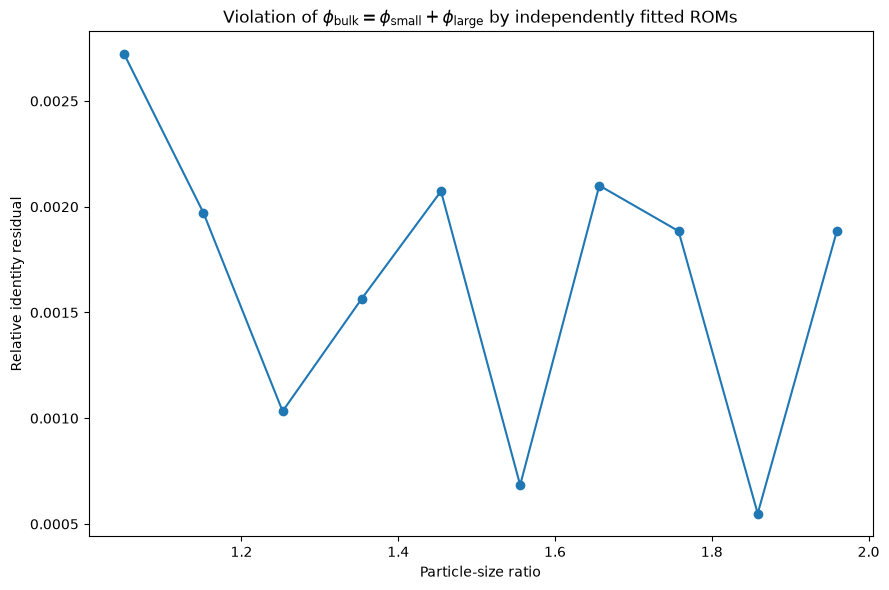


Saved identity diagnostics:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_identity_diagnostics.csv

Saved identity-residual figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_multifield_identity_residual.pdf


,original_index,size_ratio,independent_identity_error,direct_bulk_error,bulk_from_species_error,direct_small_error,small_from_bulk_large_error,direct_large_error,large_from_bulk_small_error
0,5,1.050505,0.002721,0.006923,0.007048,0.020261,0.021605,0.020069,0.019180
1,15,1.151515,0.001971,0.002698,0.002866,0.009318,0.009553,0.008641,0.009019
2,25,1.252525,0.001033,0.003050,0.003220,0.005775,0.006034,0.006329,0.006072
3,35,1.353535,0.001566,0.002662,0.003166,0.012199,0.011132,0.011054,0.012126
4,45,1.454545,0.002073,0.003394,0.003590,0.006150,0.007684,0.007831,0.006936
5,55,1.555556,0.000684,0.004593,0.004762,0.007803,0.007732,0.008210,0.008064
6,65,1.656566,0.002100,0.005635,0.006354,0.007848,0.006035,0.009013,0.009769
7,75,1.757576,0.001885,0.002629,0.003285,0.010078,0.011938,0.012877,0.010953
8,85,1.858586,0.000549,0.004848,0.005170,0.008389,0.008263,0.010547,0.010228
9,95,1.959596,0.001885,0.002824,0.003447,0.006219,0.005120,0.006464,0.007381


In [15]:
predicted_bulk = reserved_predictions[
    "bulk"
][
    "neural_snapshots"
]

predicted_small = reserved_predictions[
    "small"
][
    "neural_snapshots"
]

predicted_large = reserved_predictions[
    "large"
][
    "neural_snapshots"
]

exact_bulk = reserved_predictions[
    "bulk"
][
    "exact_snapshots"
]

exact_small = reserved_predictions[
    "small"
][
    "exact_snapshots"
]

exact_large = reserved_predictions[
    "large"
][
    "exact_snapshots"
]


independent_identity_residual = (
    predicted_bulk
    - predicted_small
    - predicted_large
)

relative_identity_errors = (
    np.linalg.norm(
        independent_identity_residual,
        axis=0,
    )
    / np.linalg.norm(
        exact_bulk,
        axis=0,
    )
)


# Three possible consistency-enforced constructions.
bulk_from_species = (
    predicted_small
    + predicted_large
)

small_from_bulk_large = (
    predicted_bulk
    - predicted_large
)

large_from_bulk_small = (
    predicted_bulk
    - predicted_small
)

bulk_from_species_errors = (
    relative_snapshot_errors(
        exact_bulk,
        bulk_from_species,
    )
)

small_from_bulk_large_errors = (
    relative_snapshot_errors(
        exact_small,
        small_from_bulk_large,
    )
)

large_from_bulk_small_errors = (
    relative_snapshot_errors(
        exact_large,
        large_from_bulk_small,
    )
)


identity_records = []

for test_index, original_index in enumerate(
    reserved_test_indices
):
    identity_records.append(
        {
            "original_index": int(
                original_index
            ),
            "size_ratio": float(
                parameters[
                    original_index
                ]
            ),
            "independent_identity_error": float(
                relative_identity_errors[
                    test_index
                ]
            ),
            "direct_bulk_error": float(
                reserved_predictions[
                    "bulk"
                ][
                    "neural_errors"
                ][test_index]
            ),
            "bulk_from_species_error": float(
                bulk_from_species_errors[
                    test_index
                ]
            ),
            "direct_small_error": float(
                reserved_predictions[
                    "small"
                ][
                    "neural_errors"
                ][test_index]
            ),
            "small_from_bulk_large_error": float(
                small_from_bulk_large_errors[
                    test_index
                ]
            ),
            "direct_large_error": float(
                reserved_predictions[
                    "large"
                ][
                    "neural_errors"
                ][test_index]
            ),
            "large_from_bulk_small_error": float(
                large_from_bulk_small_errors[
                    test_index
                ]
            ),
        }
    )


identity_diagnostics = pd.DataFrame(
    identity_records
)

print("Multifield consistency diagnostics")
print("----------------------------------")

print(
    "Mean independent identity residual:",
    f"{relative_identity_errors.mean():.6e}",
)

print(
    "Maximum independent identity residual:",
    f"{relative_identity_errors.max():.6e}",
)

print(
    "\nMean direct bulk error:",
    f"{reserved_predictions['bulk']['neural_errors'].mean():.6e}",
)

print(
    "Mean bulk-from-species error:",
    f"{bulk_from_species_errors.mean():.6e}",
)

print(
    "\nMean direct small error:",
    f"{reserved_predictions['small']['neural_errors'].mean():.6e}",
)

print(
    "Mean small-from-bulk-large error:",
    f"{small_from_bulk_large_errors.mean():.6e}",
)

print(
    "\nMean direct large error:",
    f"{reserved_predictions['large']['neural_errors'].mean():.6e}",
)

print(
    "Mean large-from-bulk-small error:",
    f"{large_from_bulk_small_errors.mean():.6e}",
)


identity_path = (
    TABLE_DIR
    / "cg_phi_multifield_identity_diagnostics.csv"
)

identity_diagnostics.to_csv(
    identity_path,
    index=False,
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    identity_diagnostics[
        "size_ratio"
    ],
    identity_diagnostics[
        "independent_identity_error"
    ],
    marker="o",
)

plt.xlabel(
    "Particle-size ratio"
)

plt.ylabel(
    "Relative identity residual"
)

plt.title(
    "Violation of "
    r"$\phi_{\mathrm{bulk}}="
    r"\phi_{\mathrm{small}}+\phi_{\mathrm{large}}$ "
    "by independently fitted ROMs"
)

plt.tight_layout()

identity_figure_path = (
    FIGURE_DIR
    / "cg_phi_multifield_identity_residual.pdf"
)

plt.savefig(
    identity_figure_path,
    bbox_inches="tight",
)

plt.show()

print("\nSaved identity diagnostics:")
print(identity_path)

print("\nSaved identity-residual figure:")
print(identity_figure_path)

display(
    identity_diagnostics
)

In [16]:
x_spacing = float(
    np.mean(
        np.diff(x_grid)
    )
)

z_spacing = float(
    np.mean(
        np.diff(z_grid)
    )
)

cell_area = (
    x_spacing
    * z_spacing
)

physical_diagnostic_records = []

for field_name in [
    "bulk",
    "small",
    "large",
]:
    exact_snapshots = reserved_predictions[
        field_name
    ][
        "exact_snapshots"
    ]

    predicted_snapshots = reserved_predictions[
        field_name
    ][
        "neural_snapshots"
    ]

    field_errors = reserved_predictions[
        field_name
    ][
        "neural_errors"
    ]

    for local_index, original_index in enumerate(
        reserved_test_indices
    ):
        exact_snapshot = exact_snapshots[
            :,
            local_index,
        ]

        predicted_snapshot = predicted_snapshots[
            :,
            local_index,
        ]

        exact_integrated_volume = float(
            exact_snapshot.sum()
            * cell_area
        )

        predicted_integrated_volume = float(
            predicted_snapshot.sum()
            * cell_area
        )

        relative_volume_error = float(
            abs(
                predicted_integrated_volume
                - exact_integrated_volume
            )
            / abs(
                exact_integrated_volume
            )
        )

        physical_diagnostic_records.append(
            {
                "field": field_name,
                "selected_rank": int(
                    locked_multifield_models[
                        field_name
                    ][
                        "rank"
                    ]
                ),
                "original_index": int(
                    original_index
                ),
                "size_ratio": float(
                    parameters[
                        original_index
                    ]
                ),
                "relative_field_error": float(
                    field_errors[
                        local_index
                    ]
                ),
                "exact_integrated_volume": (
                    exact_integrated_volume
                ),
                "predicted_integrated_volume": (
                    predicted_integrated_volume
                ),
                "relative_volume_error": (
                    relative_volume_error
                ),
                "predicted_minimum": float(
                    predicted_snapshot.min()
                ),
                "predicted_maximum": float(
                    predicted_snapshot.max()
                ),
                "fraction_below_zero": float(
                    np.mean(
                        predicted_snapshot
                        < 0.0
                    )
                ),
                "fraction_below_minus_1e_6": float(
                    np.mean(
                        predicted_snapshot
                        < -1e-6
                    )
                ),
                "fraction_below_minus_1e_5": float(
                    np.mean(
                        predicted_snapshot
                        < -1e-5
                    )
                ),
                "fraction_above_one": float(
                    np.mean(
                        predicted_snapshot
                        > 1.0
                    )
                ),
            }
        )


multifield_physical_diagnostics = pd.DataFrame(
    physical_diagnostic_records
)

multifield_physical_summary = (
    multifield_physical_diagnostics
    .groupby(
        "field",
        as_index=False,
    )
    .agg(
        mean_field_error=(
            "relative_field_error",
            "mean",
        ),
        maximum_field_error=(
            "relative_field_error",
            "max",
        ),
        mean_volume_error=(
            "relative_volume_error",
            "mean",
        ),
        maximum_volume_error=(
            "relative_volume_error",
            "max",
        ),
        minimum_prediction=(
            "predicted_minimum",
            "min",
        ),
        maximum_prediction=(
            "predicted_maximum",
            "max",
        ),
        maximum_fraction_below_minus_1e_6=(
            "fraction_below_minus_1e_6",
            "max",
        ),
        maximum_fraction_below_minus_1e_5=(
            "fraction_below_minus_1e_5",
            "max",
        ),
        maximum_fraction_above_one=(
            "fraction_above_one",
            "max",
        ),
    )
)

print("Multifield physical diagnostics")
print("-------------------------------")

display(
    multifield_physical_summary
)


physical_detailed_path = (
    TABLE_DIR
    / "cg_phi_multifield_physical_diagnostics.csv"
)

physical_summary_path = (
    TABLE_DIR
    / "cg_phi_multifield_physical_summary.csv"
)

multifield_physical_diagnostics.to_csv(
    physical_detailed_path,
    index=False,
)

multifield_physical_summary.to_csv(
    physical_summary_path,
    index=False,
)

print("Saved detailed physical diagnostics:")
print(physical_detailed_path)

print("\nSaved physical summary:")
print(physical_summary_path)

Multifield physical diagnostics
-------------------------------


,field,mean_field_error,maximum_field_error,mean_volume_error,maximum_volume_error,minimum_prediction,maximum_prediction,maximum_fraction_below_minus_1e_6,maximum_fraction_below_minus_1e_5,maximum_fraction_above_one
0,bulk,0.003926,0.006923,0.000036,0.000074,-0.000003,0.574782,0.0033,0.0000,0.0
1,large,0.010104,0.020069,0.000078,0.000167,-0.002595,0.482300,0.0109,0.0107,0.0
2,small,0.009404,0.020261,0.000027,0.000067,-0.000002,0.537452,0.0020,0.0000,0.0


Saved detailed physical diagnostics:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_physical_diagnostics.csv

Saved physical summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_physical_summary.csv


In [17]:
training_cv_error_by_field = (
    multifield_robust_selection
    .set_index(
        "field"
    )[
        "selected_mean_cv_error"
    ]
    .to_dict()
)

deployment_pair_definitions = {
    "bulk_small_derive_large": {
        "modelled_fields": (
            "bulk",
            "small",
        ),
        "derived_field": "large",
    },
    "bulk_large_derive_small": {
        "modelled_fields": (
            "bulk",
            "large",
        ),
        "derived_field": "small",
    },
    "small_large_derive_bulk": {
        "modelled_fields": (
            "small",
            "large",
        ),
        "derived_field": "bulk",
    },
}

training_selection_records = []

for strategy_name, strategy_definition in (
    deployment_pair_definitions.items()
):
    modelled_fields = strategy_definition[
        "modelled_fields"
    ]

    modelled_cv_errors = [
        training_cv_error_by_field[
            field_name
        ]
        for field_name in modelled_fields
    ]

    training_selection_records.append(
        {
            "strategy": strategy_name,
            "first_modelled_field": (
                modelled_fields[0]
            ),
            "second_modelled_field": (
                modelled_fields[1]
            ),
            "derived_field": (
                strategy_definition[
                    "derived_field"
                ]
            ),
            "mean_training_cv_error": float(
                np.mean(
                    modelled_cv_errors
                )
            ),
            "sum_training_cv_error": float(
                np.sum(
                    modelled_cv_errors
                )
            ),
        }
    )


training_deployment_selection = pd.DataFrame(
    training_selection_records
).sort_values(
    "mean_training_cv_error"
).reset_index(
    drop=True
)

selected_deployment_strategy = (
    training_deployment_selection.loc[
        0,
        "strategy",
    ]
)

print("Training-only deployment selection")
print("----------------------------------")

display(
    training_deployment_selection
)

print(
    "Selected strategy:",
    selected_deployment_strategy,
)

assert (
    selected_deployment_strategy
    == "bulk_small_derive_large"
)


direct_predictions = {
    field_name: reserved_predictions[
        field_name
    ][
        "neural_snapshots"
    ]
    for field_name in [
        "bulk",
        "small",
        "large",
    ]
}

strategy_predictions = {
    "independent_three_models": {
        "bulk": direct_predictions[
            "bulk"
        ],
        "small": direct_predictions[
            "small"
        ],
        "large": direct_predictions[
            "large"
        ],
    },
    "bulk_small_derive_large": {
        "bulk": direct_predictions[
            "bulk"
        ],
        "small": direct_predictions[
            "small"
        ],
        "large": (
            direct_predictions[
                "bulk"
            ]
            - direct_predictions[
                "small"
            ]
        ),
    },
    "bulk_large_derive_small": {
        "bulk": direct_predictions[
            "bulk"
        ],
        "small": (
            direct_predictions[
                "bulk"
            ]
            - direct_predictions[
                "large"
            ]
        ),
        "large": direct_predictions[
            "large"
        ],
    },
    "small_large_derive_bulk": {
        "bulk": (
            direct_predictions[
                "small"
            ]
            + direct_predictions[
                "large"
            ]
        ),
        "small": direct_predictions[
            "small"
        ],
        "large": direct_predictions[
            "large"
        ],
    },
}


deployment_comparison_records = []

for strategy_name, predictions in (
    strategy_predictions.items()
):
    field_errors = {}

    for field_name in [
        "bulk",
        "small",
        "large",
    ]:
        field_errors[
            field_name
        ] = relative_snapshot_errors(
            reserved_predictions[
                field_name
            ][
                "exact_snapshots"
            ],
            predictions[
                field_name
            ],
        )

    identity_residuals = (
        np.linalg.norm(
            predictions["bulk"]
            - predictions["small"]
            - predictions["large"],
            axis=0,
        )
        / np.linalg.norm(
            reserved_predictions[
                "bulk"
            ][
                "exact_snapshots"
            ],
            axis=0,
        )
    )

    deployment_comparison_records.append(
        {
            "strategy": strategy_name,
            "mean_bulk_error": float(
                field_errors[
                    "bulk"
                ].mean()
            ),
            "mean_small_error": float(
                field_errors[
                    "small"
                ].mean()
            ),
            "mean_large_error": float(
                field_errors[
                    "large"
                ].mean()
            ),
            "mean_error_across_fields": float(
                np.mean(
                    [
                        field_errors[
                            "bulk"
                        ].mean(),
                        field_errors[
                            "small"
                        ].mean(),
                        field_errors[
                            "large"
                        ].mean(),
                    ]
                )
            ),
            "maximum_error_across_all_cases": float(
                max(
                    field_errors[
                        "bulk"
                    ].max(),
                    field_errors[
                        "small"
                    ].max(),
                    field_errors[
                        "large"
                    ].max(),
                )
            ),
            "mean_identity_residual": float(
                identity_residuals.mean()
            ),
            "maximum_identity_residual": float(
                identity_residuals.max()
            ),
        }
    )


deployment_strategy_comparison = pd.DataFrame(
    deployment_comparison_records
).sort_values(
    "mean_error_across_fields"
).reset_index(
    drop=True
)

consistent_predictions = (
    strategy_predictions[
        selected_deployment_strategy
    ]
)

print(
    "\nReserved-case deployment comparison"
)

display(
    deployment_strategy_comparison
)


deployment_selection_path = (
    TABLE_DIR
    / "cg_phi_multifield_training_deployment_selection.csv"
)

deployment_comparison_path = (
    TABLE_DIR
    / "cg_phi_multifield_deployment_strategy_comparison.csv"
)

training_deployment_selection.to_csv(
    deployment_selection_path,
    index=False,
)

deployment_strategy_comparison.to_csv(
    deployment_comparison_path,
    index=False,
)

print("\nSaved training-only selection:")
print(deployment_selection_path)

print("\nSaved deployment comparison:")
print(deployment_comparison_path)

Training-only deployment selection
----------------------------------


,strategy,first_modelled_field,second_modelled_field,derived_field,mean_training_cv_error,sum_training_cv_error
0,bulk_small_derive_large,bulk,small,large,0.006442,0.012884
1,bulk_large_derive_small,bulk,large,small,0.006935,0.013869
2,small_large_derive_bulk,small,large,bulk,0.009712,0.019425


Selected strategy: bulk_small_derive_large

Reserved-case deployment comparison


,strategy,mean_bulk_error,mean_small_error,mean_large_error,mean_error_across_fields,maximum_error_across_all_cases,mean_identity_residual,maximum_identity_residual
0,bulk_small_derive_large,0.003926,0.009404,0.009973,0.007768,0.020261,0.000000e+00,0.000000e+00
1,independent_three_models,0.003926,0.009404,0.010104,0.007811,0.020261,1.646860e-03,2.720953e-03
2,bulk_large_derive_small,0.003926,0.009510,0.010104,0.007846,0.021605,2.345028e-17,2.833352e-17
3,small_large_derive_bulk,0.004291,0.009404,0.010104,0.007933,0.020261,6.307659e-17,6.612263e-17



Saved training-only selection:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_training_deployment_selection.csv

Saved deployment comparison:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_multifield_deployment_strategy_comparison.csv


In [18]:
consistent_physical_records = []

for field_name in [
    "bulk",
    "small",
    "large",
]:
    exact_snapshots = reserved_predictions[
        field_name
    ][
        "exact_snapshots"
    ]

    predicted_snapshots = (
        consistent_predictions[
            field_name
        ]
    )

    field_errors = relative_snapshot_errors(
        exact_snapshots,
        predicted_snapshots,
    )

    for local_index, original_index in enumerate(
        reserved_test_indices
    ):
        exact_snapshot = exact_snapshots[
            :,
            local_index,
        ]

        predicted_snapshot = (
            predicted_snapshots[
                :,
                local_index,
            ]
        )

        exact_volume = float(
            exact_snapshot.sum()
            * cell_area
        )

        predicted_volume = float(
            predicted_snapshot.sum()
            * cell_area
        )

        consistent_physical_records.append(
            {
                "field": field_name,
                "prediction_role": (
                    "derived"
                    if field_name == "large"
                    else "direct_rom"
                ),
                "original_index": int(
                    original_index
                ),
                "size_ratio": float(
                    parameters[
                        original_index
                    ]
                ),
                "relative_field_error": float(
                    field_errors[
                        local_index
                    ]
                ),
                "exact_integrated_volume": (
                    exact_volume
                ),
                "predicted_integrated_volume": (
                    predicted_volume
                ),
                "relative_volume_error": float(
                    abs(
                        predicted_volume
                        - exact_volume
                    )
                    / abs(
                        exact_volume
                    )
                ),
                "predicted_minimum": float(
                    predicted_snapshot.min()
                ),
                "predicted_maximum": float(
                    predicted_snapshot.max()
                ),
                "fraction_below_zero": float(
                    np.mean(
                        predicted_snapshot
                        < 0.0
                    )
                ),
                "fraction_below_minus_1e_6": float(
                    np.mean(
                        predicted_snapshot
                        < -1e-6
                    )
                ),
                "fraction_below_minus_1e_5": float(
                    np.mean(
                        predicted_snapshot
                        < -1e-5
                    )
                ),
                "fraction_above_one": float(
                    np.mean(
                        predicted_snapshot
                        > 1.0
                    )
                ),
            }
        )


consistent_physical_diagnostics = pd.DataFrame(
    consistent_physical_records
)

consistent_physical_summary = (
    consistent_physical_diagnostics
    .groupby(
        [
            "field",
            "prediction_role",
        ],
        as_index=False,
    )
    .agg(
        mean_field_error=(
            "relative_field_error",
            "mean",
        ),
        maximum_field_error=(
            "relative_field_error",
            "max",
        ),
        mean_volume_error=(
            "relative_volume_error",
            "mean",
        ),
        maximum_volume_error=(
            "relative_volume_error",
            "max",
        ),
        minimum_prediction=(
            "predicted_minimum",
            "min",
        ),
        maximum_prediction=(
            "predicted_maximum",
            "max",
        ),
        maximum_fraction_below_minus_1e_6=(
            "fraction_below_minus_1e_6",
            "max",
        ),
        maximum_fraction_below_minus_1e_5=(
            "fraction_below_minus_1e_5",
            "max",
        ),
        maximum_fraction_above_one=(
            "fraction_above_one",
            "max",
        ),
    )
)


consistent_identity_residual = (
    consistent_predictions[
        "bulk"
    ]
    - consistent_predictions[
        "small"
    ]
    - consistent_predictions[
        "large"
    ]
)

maximum_consistent_identity_error = float(
    np.max(
        np.abs(
            consistent_identity_residual
        )
    )
)

print("Consistent two-ROM physical diagnostics")
print("---------------------------------------")

display(
    consistent_physical_summary
)

print(
    "Maximum pointwise identity error:",
    f"{maximum_consistent_identity_error:.6e}",
)

assert maximum_consistent_identity_error < 1e-12


consistent_physical_detailed_path = (
    TABLE_DIR
    / "cg_phi_consistent_rom_physical_diagnostics.csv"
)

consistent_physical_summary_path = (
    TABLE_DIR
    / "cg_phi_consistent_rom_physical_summary.csv"
)

consistent_physical_diagnostics.to_csv(
    consistent_physical_detailed_path,
    index=False,
)

consistent_physical_summary.to_csv(
    consistent_physical_summary_path,
    index=False,
)

print("\nSaved detailed diagnostics:")
print(consistent_physical_detailed_path)

print("\nSaved physical summary:")
print(consistent_physical_summary_path)

print(
    "\nNo clipping or post-processing "
    "has been applied to the predictions."
)

Consistent two-ROM physical diagnostics
---------------------------------------


,field,prediction_role,mean_field_error,maximum_field_error,mean_volume_error,maximum_volume_error,minimum_prediction,maximum_prediction,maximum_fraction_below_minus_1e_6,maximum_fraction_below_minus_1e_5,maximum_fraction_above_one
0,bulk,direct_rom,0.003926,0.006923,0.000036,0.000074,-0.000003,0.574782,0.0033,0.0000,0.0
1,large,derived,0.009973,0.019180,0.000077,0.000171,-0.001232,0.481848,0.0069,0.0046,0.0
2,small,direct_rom,0.009404,0.020261,0.000027,0.000067,-0.000002,0.537452,0.0020,0.0000,0.0


Maximum pointwise identity error: 0.000000e+00

Saved detailed diagnostics:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_consistent_rom_physical_diagnostics.csv

Saved physical summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_consistent_rom_physical_summary.csv

No clipping or post-processing has been applied to the predictions.


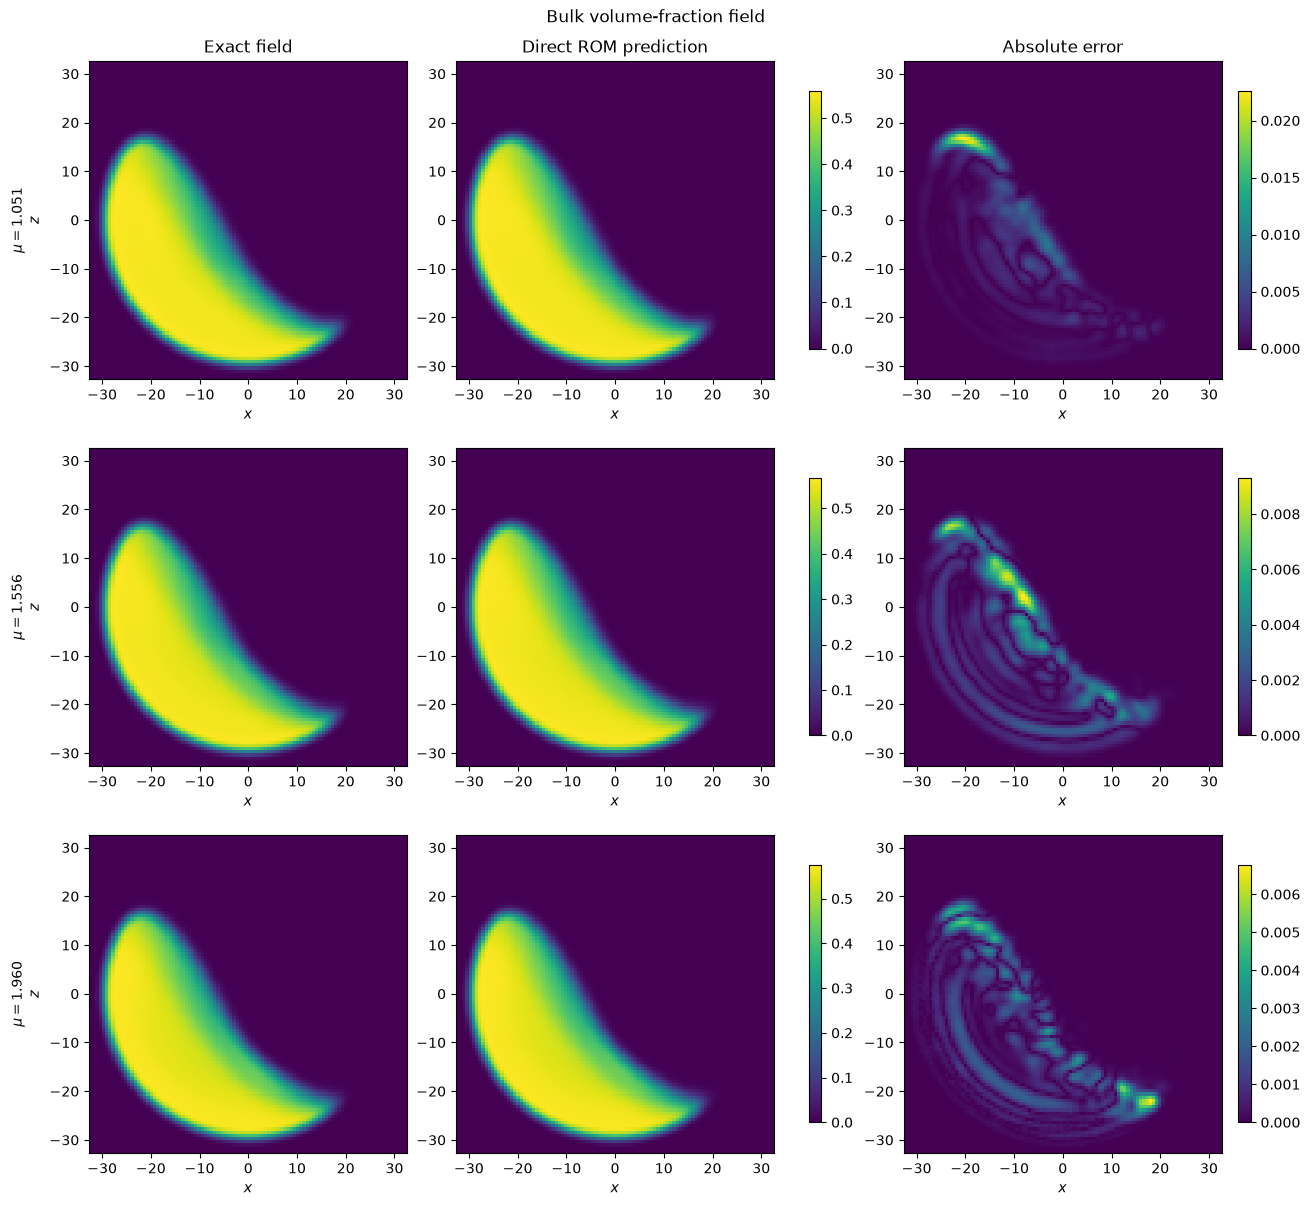

Saved bulk reconstruction figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_consistent_rom_bulk_reconstructions.pdf


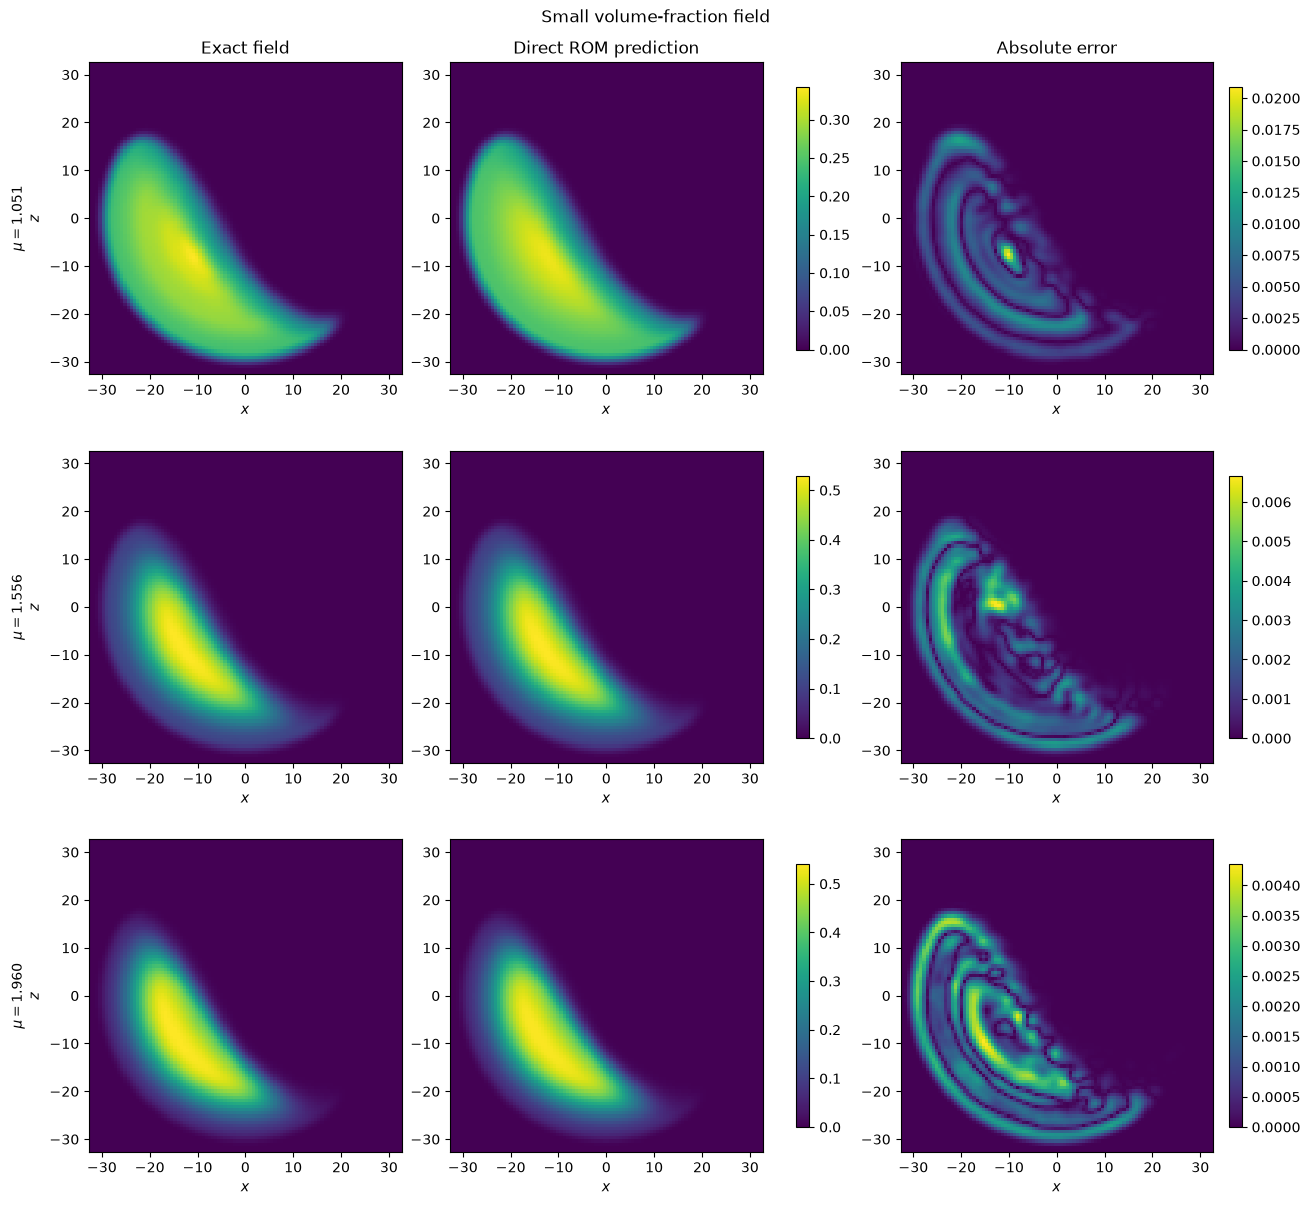

Saved small reconstruction figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_consistent_rom_small_reconstructions.pdf


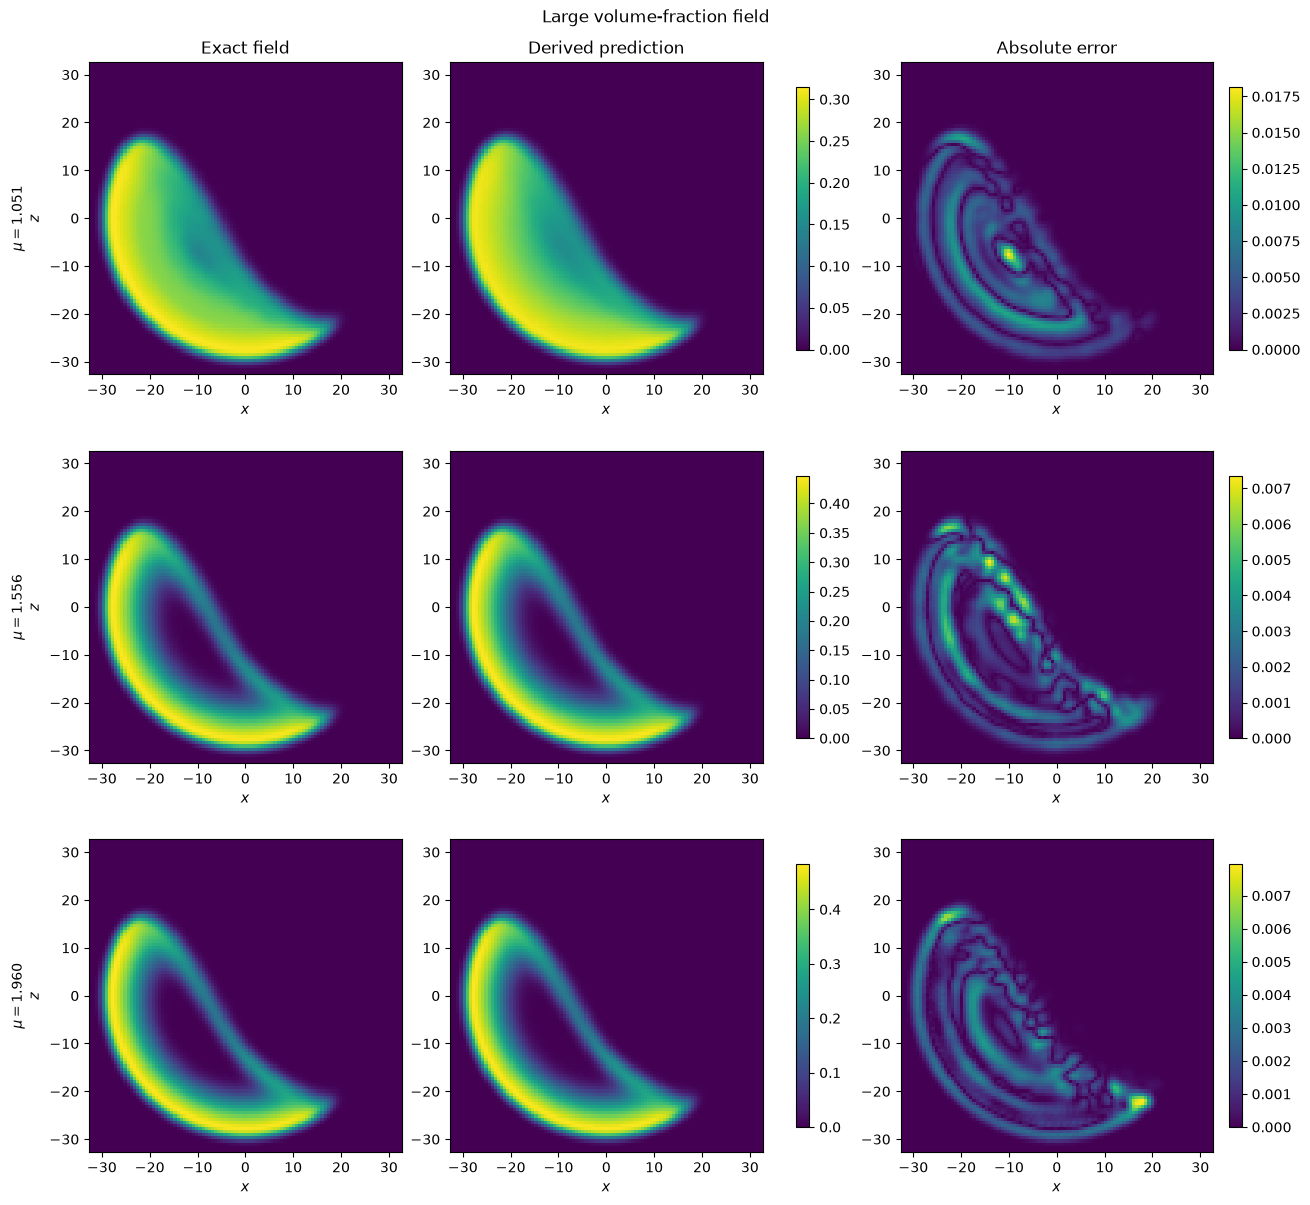

Saved large reconstruction figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_consistent_rom_large_reconstructions.pdf


In [19]:
def snapshot_to_field(
    snapshot: np.ndarray,
) -> np.ndarray:
    """Convert the flattened MercuryCG ordering to a z-by-x field."""
    return snapshot.reshape(
        x_grid.size,
        z_grid.size,
    ).T


representative_test_positions = [
    0,
    5,
    9,
]

representative_parameters = (
    reserved_test_parameters[
        representative_test_positions
    ]
)

consistent_field_figure_paths = {}

for field_name in [
    "bulk",
    "small",
    "large",
]:
    exact_snapshots = reserved_predictions[
        field_name
    ][
        "exact_snapshots"
    ]

    predicted_snapshots = (
        consistent_predictions[
            field_name
        ]
    )

    figure, axes = plt.subplots(
        len(
            representative_test_positions
        ),
        3,
        figsize=(13, 12),
        constrained_layout=True,
    )

    for row_index, test_position in enumerate(
        representative_test_positions
    ):
        exact_field = snapshot_to_field(
            exact_snapshots[
                :,
                test_position,
            ]
        )

        predicted_field = snapshot_to_field(
            predicted_snapshots[
                :,
                test_position,
            ]
        )

        absolute_error_field = np.abs(
            predicted_field
            - exact_field
        )

        shared_maximum = float(
            max(
                exact_field.max(),
                predicted_field.max(),
            )
        )

        error_maximum = float(
            absolute_error_field.max()
        )

        exact_image = axes[
            row_index,
            0,
        ].imshow(
            exact_field,
            origin="lower",
            extent=(
                x_grid.min(),
                x_grid.max(),
                z_grid.min(),
                z_grid.max(),
            ),
            aspect="equal",
            interpolation="nearest",
            vmin=0.0,
            vmax=shared_maximum,
        )

        axes[
            row_index,
            1,
        ].imshow(
            predicted_field,
            origin="lower",
            extent=(
                x_grid.min(),
                x_grid.max(),
                z_grid.min(),
                z_grid.max(),
            ),
            aspect="equal",
            interpolation="nearest",
            vmin=0.0,
            vmax=shared_maximum,
        )

        error_image = axes[
            row_index,
            2,
        ].imshow(
            absolute_error_field,
            origin="lower",
            extent=(
                x_grid.min(),
                x_grid.max(),
                z_grid.min(),
                z_grid.max(),
            ),
            aspect="equal",
            interpolation="nearest",
            vmin=0.0,
            vmax=error_maximum,
        )

        size_ratio = representative_parameters[
            row_index
        ]

        axes[
            row_index,
            0,
        ].set_ylabel(
            rf"$\mu={size_ratio:.3f}$"
            "\n"
            r"$z$"
        )

        figure.colorbar(
            exact_image,
            ax=[
                axes[
                    row_index,
                    0,
                ],
                axes[
                    row_index,
                    1,
                ],
            ],
            shrink=0.75,
        )

        figure.colorbar(
            error_image,
            ax=axes[
                row_index,
                2,
            ],
            shrink=0.75,
        )

    axes[
        0,
        0,
    ].set_title(
        "Exact field"
    )

    prediction_label = (
        "Derived prediction"
        if field_name == "large"
        else "Direct ROM prediction"
    )

    axes[
        0,
        1,
    ].set_title(
        prediction_label
    )

    axes[
        0,
        2,
    ].set_title(
        "Absolute error"
    )

    for axis in axes.ravel():
        axis.set_xlabel(
            r"$x$"
        )

    figure.suptitle(
        f"{field_name.capitalize()} volume-fraction field"
    )

    field_figure_path = (
        FIGURE_DIR
        / (
            "cg_phi_consistent_rom_"
            f"{field_name}_reconstructions.pdf"
        )
    )

    figure.savefig(
        field_figure_path,
        bbox_inches="tight",
    )

    plt.show()

    consistent_field_figure_paths[
        field_name
    ] = field_figure_path

    print(
        f"Saved {field_name} reconstruction figure:"
    )

    print(
        field_figure_path
    )

In [21]:
import joblib


def predict_consistent_rom_package(
    package: dict,
    query_parameters: np.ndarray,
) -> dict:
    """
    Predict bulk and small fields and derive the large field exactly.
    """
    query_parameters = np.asarray(
        query_parameters,
        dtype=float,
    )

    predictions = {}

    for field_name in package[
        "direct_model_fields"
    ]:
        model = package[
            "models"
        ][
            field_name
        ]

        _, field_prediction = (
            predict_locked_neural_model(
                model,
                query_parameters,
            )
        )

        predictions[
            field_name
        ] = field_prediction

    predictions["large"] = (
        predictions["bulk"]
        - predictions["small"]
    )

    return predictions


consistent_package_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cg_phi_consistent_bulk_small_rom.joblib"
)

consistent_rom_package = {
    "schema_version": 1,
    "description": (
        "Physically consistent volume-fraction ROM. "
        "Bulk and small-species fields are predicted "
        "directly and the large-species field is derived "
        "as bulk minus small."
    ),
    "deployment_strategy": (
        selected_deployment_strategy
    ),
    "direct_model_fields": (
        "bulk",
        "small",
    ),
    "derived_field": "large",
    "physical_identity": (
        "bulk = small + large"
    ),
    "x_grid": x_grid,
    "z_grid": z_grid,
    "output_time": output_time,
    "training_parameter_minimum": float(
        parameters[
            model_training_indices
        ].min()
    ),
    "training_parameter_maximum": float(
        parameters[
            model_training_indices
        ].max()
    ),
    "training_indices": (
        model_training_indices
    ),
    "reserved_test_indices": (
        reserved_test_indices
    ),
    "models": {
        "bulk": locked_multifield_models[
            "bulk"
        ],
        "small": locked_multifield_models[
            "small"
        ],
    },
}

joblib.dump(
    consistent_rom_package,
    consistent_package_path,
    compress=3,
)

reloaded_consistent_package = joblib.load(
    consistent_package_path
)

reloaded_predictions = (
    predict_consistent_rom_package(
        reloaded_consistent_package,
        reserved_test_parameters,
    )
)

reload_difference_records = []

for field_name in [
    "bulk",
    "small",
    "large",
]:
    maximum_reload_difference = float(
        np.max(
            np.abs(
                reloaded_predictions[
                    field_name
                ]
                - consistent_predictions[
                    field_name
                ]
            )
        )
    )

    reload_difference_records.append(
        {
            "field": field_name,
            "maximum_reload_difference": (
                maximum_reload_difference
            ),
        }
    )

    assert maximum_reload_difference < 1e-12


package_reload_validation = pd.DataFrame(
    reload_difference_records
)

package_size_mb = (
    consistent_package_path.stat().st_size
    / 1024**2
)

manifest_records = []

for field_name in [
    "bulk",
    "small",
    "large",
]:
    physical_row = (
        consistent_physical_summary.loc[
            consistent_physical_summary[
                "field"
            ]
            == field_name
        ]
        .iloc[0]
    )

    if field_name in (
        "bulk",
        "small",
    ):
        model_role = "direct_rom"

        selected_rank = int(
            locked_multifield_models[
                field_name
            ][
                "rank"
            ]
        )

        training_cv_error = float(
            training_cv_error_by_field[
                field_name
            ]
        )

    else:
        model_role = (
            "derived_as_bulk_minus_small"
        )

        selected_rank = np.nan
        training_cv_error = np.nan

    manifest_records.append(
        {
            "field": field_name,
            "role": model_role,
            "selected_rank": selected_rank,
            "training_cv_error": (
                training_cv_error
            ),
            "reserved_mean_error": float(
                physical_row[
                    "mean_field_error"
                ]
            ),
            "reserved_maximum_error": float(
                physical_row[
                    "maximum_field_error"
                ]
            ),
            "reserved_mean_volume_error": float(
                physical_row[
                    "mean_volume_error"
                ]
            ),
            "minimum_prediction": float(
                physical_row[
                    "minimum_prediction"
                ]
            ),
        }
    )


consistent_rom_manifest = pd.DataFrame(
    manifest_records
)

manifest_path = (
    TABLE_DIR
    / "cg_phi_consistent_rom_manifest.csv"
)

reload_validation_path = (
    TABLE_DIR
    / "cg_phi_consistent_rom_reload_validation.csv"
)

consistent_rom_manifest.to_csv(
    manifest_path,
    index=False,
)

package_reload_validation.to_csv(
    reload_validation_path,
    index=False,
)


bulk_manifest = consistent_rom_manifest.loc[
    consistent_rom_manifest[
        "field"
    ]
    == "bulk"
].iloc[0]

small_manifest = consistent_rom_manifest.loc[
    consistent_rom_manifest[
        "field"
    ]
    == "small"
].iloc[0]

large_manifest = consistent_rom_manifest.loc[
    consistent_rom_manifest[
        "field"
    ]
    == "large"
].iloc[0]


consistent_conclusion = f"""
## Final consistent multifield ROM

Training-only cross-validation selected the bulk and small-species models as
the two most accurate independently fitted ROMs. Their selected POD ranks are
{int(bulk_manifest["selected_rank"])} and
{int(small_manifest["selected_rank"])}, respectively.

The large-species prediction is calculated algebraically as

$$
\\widehat{{\\phi}}_{{\\mathrm{{large}}}}
=
\\widehat{{\\phi}}_{{\\mathrm{{bulk}}}}
-
\\widehat{{\\phi}}_{{\\mathrm{{small}}}}.
$$

This reduces the deployed system from three neural ROMs to two and guarantees

$$
\\widehat{{\\phi}}_{{\\mathrm{{bulk}}}}
=
\\widehat{{\\phi}}_{{\\mathrm{{small}}}}
+
\\widehat{{\\phi}}_{{\\mathrm{{large}}}}
$$

to machine precision.

On the ten internally reserved simulations, the mean relative errors are:

- {100 * bulk_manifest["reserved_mean_error"]:.4f}% for the bulk field;
- {100 * small_manifest["reserved_mean_error"]:.4f}% for the small-species field;
- {100 * large_manifest["reserved_mean_error"]:.4f}% for the derived large-species field.

The internally reserved cases were excluded from POD-rank and neural-model
selection. They are an internal held-out assessment rather than an independent
external simulation dataset.

No clipping was applied to the reconstructed fields. Any small negative values
are therefore reported transparently rather than hidden by post-processing.
"""

consistent_conclusion_path = (
    TABLE_DIR
    / "cg_phi_consistent_rom_conclusions.md"
)

consistent_conclusion_path.write_text(
    consistent_conclusion.strip()
    + "\n",
    encoding="utf-8",
)

print("Final consistent-ROM manifest")
print("-----------------------------")

display(
    consistent_rom_manifest
)

print("\nReload validation:")

display(
    package_reload_validation
)

print(
    "Packaged ROM size:",
    f"{package_size_mb:.3f} MB",
)

print("\nSaved package:")
print(consistent_package_path)

print("\nSaved manifest:")
print(manifest_path)

print("\nSaved reload validation:")
print(reload_validation_path)

print("\nSaved conclusions:")
print(consistent_conclusion_path)

Final consistent-ROM manifest
-----------------------------


,field,role,selected_rank,training_cv_error,reserved_mean_error,reserved_maximum_error,reserved_mean_volume_error,minimum_prediction
0,bulk,direct_rom,6.0,0.003664,0.003926,0.006923,0.000036,-0.000003
1,small,direct_rom,3.0,0.009220,0.009404,0.020261,0.000027,-0.000002
2,large,derived_as_bulk_minus_small,NaN,NaN,0.009973,0.019180,0.000077,-0.001232



Reload validation:


,field,maximum_reload_difference
0,bulk,0.0
1,small,0.0
2,large,0.0


Packaged ROM size: 0.445 MB

Saved package:
/Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_consistent_bulk_small_rom.joblib

Saved manifest:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_consistent_rom_manifest.csv

Saved reload validation:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_consistent_rom_reload_validation.csv

Saved conclusions:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_consistent_rom_conclusions.md


## Final consistent multifield ROM

A physically consistent reduced-order model was constructed for the bulk,
small-species and large-species volume-fraction fields.

Training-only cross-validation selected the following two directly modelled
fields:

- a rank-6 POD model for the bulk volume-fraction field;
- a rank-3 POD model for the small-species volume-fraction field.

The large-species field is calculated algebraically as

$$
\widehat{\phi}_{\mathrm{large}}
=
\widehat{\phi}_{\mathrm{bulk}}
-
\widehat{\phi}_{\mathrm{small}}.
$$

This reduces the deployed system from three neural reduced-order models to two
and guarantees that

$$
\widehat{\phi}_{\mathrm{bulk}}
=
\widehat{\phi}_{\mathrm{small}}
+
\widehat{\phi}_{\mathrm{large}}
$$

is satisfied to machine precision.

### Reserved-case performance

The ten internally reserved simulations were excluded from POD-rank selection
and neural-surrogate selection. The mean relative field errors on these cases
were:

- **0.3926%** for the directly predicted bulk field;
- **0.9404%** for the directly predicted small-species field;
- **0.9973%** for the derived large-species field.

The maximum relative errors were:

- **0.6923%** for the bulk field;
- **2.0261%** for the small-species field;
- **1.9180%** for the derived large-species field.

The derived large-species prediction was slightly more accurate than the
separately fitted large-species ROM, whose mean reserved-case error was
1.0104%.

### Physical consistency

The selected two-ROM strategy produced a mean error of **0.7768%** across the
three fields, compared with **0.7811%** for three independently fitted ROMs.

The independently fitted models produced a mean relative physical-identity
residual of 0.1647%. In contrast, deriving the large-species field from the
bulk and small-species predictions reduced this residual to exactly zero
within numerical precision.

Integrated-volume conservation was also strong. Mean relative integrated-volume
errors were approximately:

- **0.0036%** for the bulk field;
- **0.0027%** for the small-species field;
- **0.0077%** for the derived large-species field.

No clipping or other post-processing was applied. Small negative reconstructed
values were therefore retained and reported transparently. The minimum
large-species prediction was approximately $-1.23\times10^{-3}$.

### Packaged model

The final physically consistent ROM package contains the bulk and
small-species POD bases, scalers and neural surrogates. Reloading the saved
package reproduced all three predicted fields with zero numerical difference.

The packaged model has a file size of approximately **0.445 MB**.

The reserved simulations provide an internal held-out assessment rather than
an independent external validation dataset, because all simulations originate
from the same supplied parameter study.